In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyoti.sparse as oti
from wdegp.wdegp import wdegp
import utils

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
def oscillatory_function_with_trend(X, alg=oti):
    x1 = X[:, 0]
    return alg.sin(10 * np.pi * x1) / (2 * x1) + (x1 - 1) ** 4

In [3]:
n_bases = 1
n_order = 2
lb_x = 0.5
ub_x = 2.5
num_points = 10

In [4]:
X_train = np.linspace(lb_x, ub_x, num_points).reshape(-1, 1)
print("Training points:", X_train.ravel())

Training points: [0.5        0.72222222 0.94444444 1.16666667 1.38888889 1.61111111
 1.83333333 2.05555556 2.27777778 2.5       ]


In [5]:
submodel_indices = [[i] for i in range(num_points)]
base_derivative_indices = utils.gen_OTI_indices(n_bases, n_order)
derivative_specs = [base_derivative_indices for _ in range(num_points)]

print(f"Number of submodels: {len(submodel_indices)}")
print(f"Derivative types per submodel: {len(base_derivative_indices)}")

Number of submodels: 10
Derivative types per submodel: 2


In [6]:
import numpy as np
import sympy as sp

# ------------------------------------------------------------
# Define the example function symbolically
# ------------------------------------------------------------
x = sp.symbols('x')
f_sym = sp.sin(10 * sp.pi * x) / (2 * x) + (x - 1)**4

# Compute first and second derivatives symbolically
f1_sym = sp.diff(f_sym, x)
f2_sym = sp.diff(f_sym, x, 2)

# Convert to callable NumPy functions
f_fun = sp.lambdify(x, f_sym, "numpy")
f1_fun = sp.lambdify(x, f1_sym, "numpy")
f2_fun = sp.lambdify(x, f2_sym, "numpy")

# ------------------------------------------------------------
# Define experiment parameters
# ------------------------------------------------------------
lb_x, ub_x = 0.5, 2.5
num_points = 10
X_train = np.linspace(lb_x, ub_x, num_points).reshape(-1, 1)

# Each submodel corresponds to one training point
submodel_indices = [[i] for i in range(num_points)]

# ------------------------------------------------------------
# Compute function values and derivatives
# ------------------------------------------------------------
y_function_values = f_fun(X_train.flatten()).reshape(-1, 1)

submodel_data = []

for k, idx in enumerate(submodel_indices):
    X_point = X_train[idx].reshape(-1)
    xval = float(X_point[0])

    # Compute derivatives analytically at the submodel point
    d1 = np.array([[f1_fun(xval)]])  # First derivative
    d2 = np.array([[f2_fun(xval)]])  # Second derivative

    # Append [all function values] + [local derivatives]
    submodel_data.append([y_function_values] + [d1, d2])

# ------------------------------------------------------------
# Display results for verification
# ------------------------------------------------------------
print("Training points (X_train):")
print(X_train.flatten())

print("\nFunction values (y_function_values):")
print(y_function_values.flatten())

print("\nExample submodel data for first training point:")
for i, data in enumerate(submodel_data[0]):
    print(f"  Element {i}: {data.flatten()}")

Training points (X_train):
[0.5        0.72222222 0.94444444 1.16666667 1.38888889 1.61111111
 1.83333333 2.05555556 2.27777778 2.5       ]

Function values (y_function_values):
[ 0.0625     -0.43905306 -0.52135928 -0.37038214 -0.10025536  0.24561416
  0.71844183  1.48098397  2.80686142  5.0625    ]

Example submodel data for first training point:
  Element 0: [ 0.0625     -0.43905306 -0.52135928 -0.37038214 -0.10025536  0.24561416
  0.71844183  1.48098397  2.80686142  5.0625    ]
  Element 1: [-31.91592654]
  Element 2: [128.66370614]


In [7]:
normalize = True
kernel = "SE"
kernel_type = "anisotropic"

gp_model = wdegp(
    X_train,
    submodel_data,
    n_order,
    n_bases,
    submodel_indices,
    derivative_specs,
    normalize=normalize,
    kernel=kernel,
    kernel_type=kernel_type
)

In [8]:
params = gp_model.optimize_hyperparameters(
     optimizer='pso',
     pop_size = 100,
     n_generations = 15,
     local_opt_every = None,
     debug = False
     )
print("Optimized hyperparameters:", params)

Stopping: maximum iterations reached --> 15
Optimized hyperparameters: [ 7.96024999e-01 -8.16485059e-03 -1.21654899e+01]


In [9]:
X_test = np.linspace(lb_x, ub_x, 250).reshape(-1, 1)
y_pred, y_cov, submodel_vals, submodel_cov = gp_model.predict(
    X_test, params, calc_cov=True, return_submodels=True
)
y_true = oscillatory_function_with_trend(X_test, alg=np)
nrmse = utils.nrmse(y_true, y_pred)
print(f"NRMSE: {nrmse:.6f}")

NRMSE: 0.010597


In [10]:
# ------------------------------------------------------------
# Verify function value interpolation
# ------------------------------------------------------------
y_pred_train = gp_model.predict(X_train, params, calc_cov=False)

print("Function value interpolation errors:")
print("=" * 80)
for i in range(num_points):
    error_abs = abs(y_pred_train[0, i] - y_function_values[i, 0])
    error_rel = error_abs / abs(y_function_values[i, 0]) if y_function_values[i, 0] != 0 else error_abs
    print(f"Point {i} (x={X_train[i, 0]:.3f}): Abs Error = {error_abs:.2e}, Rel Error = {error_rel:.2e}")

max_func_error = np.max(np.abs(y_pred_train.flatten() - y_function_values.flatten()))
print(f"\nMaximum absolute function value error: {max_func_error:.2e}")

# ------------------------------------------------------------
# Verify derivative interpolation using finite differences
# on individual submodels (before weighted combination)
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("Derivative interpolation verification:")
print("=" * 80)
print("Note: Verifying derivatives on individual submodels before weighted combination")
print("      to avoid numerical instabilities from the weighting function")
print("=" * 80)

# Use small perturbation for finite differences
h = 1e-6

for i, idx in enumerate(submodel_indices):
    x_point = X_train[idx].flatten()[0]

    # Get predictions at perturbed points from individual submodels
    X_plus = np.array([[x_point + h]])
    X_minus = np.array([[x_point - h]])
    X_center = X_train[idx].reshape(1, -1)

    # Get predictions from individual submodels (not weighted combination)
    _, submodel_vals_plus = gp_model.predict(X_plus, params, calc_cov=False, return_submodels=True)
    _, submodel_vals_minus = gp_model.predict(X_minus, params, calc_cov=False, return_submodels=True)
    _, submodel_vals_center = gp_model.predict(X_center, params, calc_cov=False, return_submodels=True)

    # First derivative via central difference on the i-th submodel
    fd_first_deriv = (submodel_vals_plus[i][0, 0] - submodel_vals_minus[i][0, 0]) / (2 * h)
    analytic_first_deriv = submodel_data[i][1][0, 0]
    error_first_abs = abs(fd_first_deriv - analytic_first_deriv)
    error_first_rel = error_first_abs / abs(analytic_first_deriv) if analytic_first_deriv != 0 else error_first_abs

    # Second derivative via central difference on the i-th submodel
    fd_second_deriv = (submodel_vals_plus[i][0, 0] - 2 * submodel_vals_center[i][0, 0] + submodel_vals_minus[i][0, 0]) / (h ** 2)
    analytic_second_deriv = submodel_data[i][2][0, 0]
    error_second_abs = abs(fd_second_deriv - analytic_second_deriv)
    error_second_rel = error_second_abs / abs(analytic_second_deriv) if analytic_second_deriv != 0 else error_second_abs

    print(f"\nSubmodel {i} at Point {i} (x = {x_point:.3f}):")
    print(f"  1st derivative - Analytic: {analytic_first_deriv:+.6f}, FD: {fd_first_deriv:+.6f}")
    print(f"                   Abs Error: {error_first_abs:.2e}, Rel Error: {error_first_rel:.2e}")
    print(f"  2nd derivative - Analytic: {analytic_second_deriv:+.6f}, FD: {fd_second_deriv:+.6f}")
    print(f"                   Abs Error: {error_second_abs:.2e}, Rel Error: {error_second_rel:.2e}")

print("\n" + "=" * 80)
print("Interpolation verification complete!")
print("Relative errors should be close to machine precision (< 1e-6)")
print("\n" + "=" * 80)
print("SUMMARY:")
print(f"  - Function values: enforced at all {num_points} training points")
print(f"  - First derivatives: verified on individual submodels at all {num_points} points")
print(f"  - Second derivatives: verified on individual submodels at all {num_points} points")
print(f"  - Each submodel: 1 training point with full derivative information")
print(f"  - Total submodels: {num_points}")
print(f"  - Verification method: Finite differences on submodels before weighting")
print("=" * 80)

Function value interpolation errors:
Point 0 (x=0.500): Abs Error = 5.55e-17, Rel Error = 8.88e-16
Point 1 (x=0.722): Abs Error = 8.33e-16, Rel Error = 1.90e-15
Point 2 (x=0.944): Abs Error = 5.55e-16, Rel Error = 1.06e-15
Point 3 (x=1.167): Abs Error = 2.22e-16, Rel Error = 6.00e-16
Point 4 (x=1.389): Abs Error = 4.72e-16, Rel Error = 4.71e-15
Point 5 (x=1.611): Abs Error = 1.67e-16, Rel Error = 6.78e-16
Point 6 (x=1.833): Abs Error = 2.22e-16, Rel Error = 3.09e-16
Point 7 (x=2.056): Abs Error = 0.00e+00, Rel Error = 0.00e+00
Point 8 (x=2.278): Abs Error = 4.44e-16, Rel Error = 1.58e-16
Point 9 (x=2.500): Abs Error = 8.88e-16, Rel Error = 1.75e-16

Maximum absolute function value error: 8.88e-16

Derivative interpolation verification:
Note: Verifying derivatives on individual submodels before weighted combination
      to avoid numerical instabilities from the weighting function

Submodel 0 at Point 0 (x = 0.500):
  1st derivative - Analytic: -31.915927, FD: -31.915927
               


Submodel 8 at Point 8 (x = 2.278):
  1st derivative - Analytic: +3.000267, FD: +3.000267
                   Abs Error: 9.86e-10, Rel Error: 3.29e-10
  2nd derivative - Analytic: -114.974318, FD: -114.975585
                   Abs Error: 1.27e-03, Rel Error: 1.10e-05

Submodel 9 at Point 9 (x = 2.500):
  1st derivative - Analytic: +7.216815, FD: +7.216815
                   Abs Error: 3.08e-10, Rel Error: 4.27e-11
  2nd derivative - Analytic: +32.026548, FD: +32.027714
                   Abs Error: 1.17e-03, Rel Error: 3.64e-05

Interpolation verification complete!
Relative errors should be close to machine precision (< 1e-6)

SUMMARY:
  - Function values: enforced at all 10 training points
  - First derivatives: verified on individual submodels at all 10 points
  - Second derivatives: verified on individual submodels at all 10 points
  - Each submodel: 1 training point with full derivative information
  - Total submodels: 10
  - Verification method: Finite differences on submodels bef

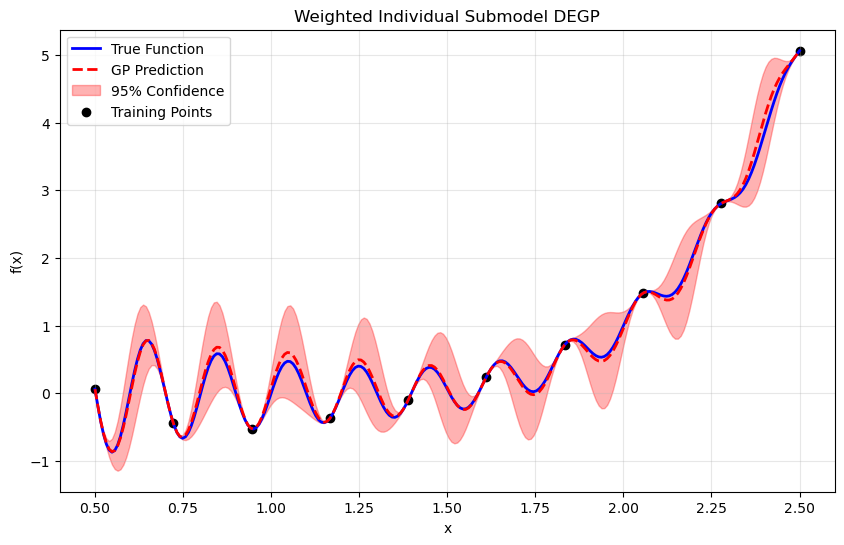

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(X_test, y_true, 'b-', label='True Function', linewidth=2)
plt.plot(X_test.flatten(), y_pred.flatten(), 'r--', label='GP Prediction', linewidth=2)
plt.fill_between(X_test.ravel(),
                 (y_pred.flatten() - 2*np.sqrt(y_cov)).ravel(),
                 (y_pred.flatten() + 2*np.sqrt(y_cov)).ravel(),
                 color='red', alpha=0.3, label='95% Confidence')
plt.scatter(X_train, y_function_values, color='black', label='Training Points')
plt.title("Weighted Individual Submodel DEGP")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

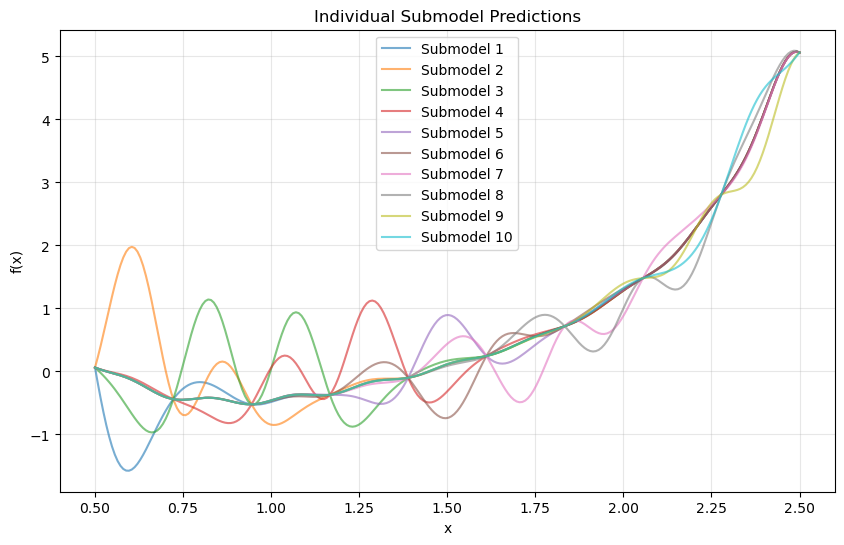

In [12]:
colors = plt.cm.tab10(np.linspace(0, 1, len(submodel_vals)))
plt.figure(figsize=(10, 6))
for i, color in enumerate(colors):
    plt.plot(X_test.flatten(), submodel_vals[i].flatten(), color=color, alpha=0.6, label=f'Submodel {i+1}')
plt.title("Individual Submodel Predictions")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from wdegp.wdegp import wdegp
import utils

In [14]:
n_order = 2
n_bases = 1
lb_x = 0.5
ub_x = 2.5
num_points = 10

In [15]:
x = sp.symbols('x')
f_sym = sp.sin(10 * sp.pi * x) / (2 * x) + (x - 1)**4

# Compute first and second derivatives symbolically
f1_sym = sp.diff(f_sym, x)
f2_sym = sp.diff(f_sym, x, 2)

# Convert to callable NumPy functions
f_fun = sp.lambdify(x, f_sym, "numpy")
f1_fun = sp.lambdify(x, f1_sym, "numpy")
f2_fun = sp.lambdify(x, f2_sym, "numpy")

In [16]:
X_train = np.linspace(lb_x, ub_x, num_points).reshape(-1, 1)
print("Training points:", X_train.ravel())

Training points: [0.5        0.72222222 0.94444444 1.16666667 1.38888889 1.61111111
 1.83333333 2.05555556 2.27777778 2.5       ]


In [17]:
# Sparse derivative selection: only include derivatives at these points
derivative_indices = [2, 3, 4, 5]

# Single submodel covering all selected derivative points
submodel_indices = [derivative_indices]

# Derivative specs: full derivative set for this submodel
base_derivative_indices = utils.gen_OTI_indices(n_bases, n_order)
derivative_specs = [base_derivative_indices]

print(f"Number of submodels: {len(submodel_indices)}")
print(f"Derivative observation points: {derivative_indices}")
print(f"Derivative types per submodel: {len(base_derivative_indices)}")

Number of submodels: 1
Derivative observation points: [2, 3, 4, 5]
Derivative types per submodel: 2


In [18]:
# Compute function values at all training points
y_function_values = f_fun(X_train.flatten()).reshape(-1, 1)

# First and second derivatives at selected derivative points only
d1_all = np.array([[f1_fun(X_train[idx, :])[0] for idx in derivative_indices]]).T
d2_all = np.array([[f2_fun(X_train[idx, :])[0] for idx in derivative_indices]]).T

# Submodel data: [[function values], [first-order derivatives], [second-order derivatives]]
submodel_data = [[y_function_values, d1_all, d2_all]]

# Display for verification
print("\nFunction values (y_function_values):")
print(y_function_values.flatten())

print("\nFirst-order derivatives at selected points:")
print(d1_all.flatten())

print("\nSecond-order derivatives at selected points:")
print(d2_all.flatten())


Function values (y_function_values):
[ 0.0625     -0.43905306 -0.52135928 -0.37038214 -0.10025536  0.24561416
  0.71844183  1.48098397  2.80686142  5.0625    ]

First-order derivatives at selected points:
[-2.33675804  7.06863456 10.95157856 10.00879899]

Second-order derivatives at selected points:
[ 519.55440399  354.56148312  107.90503355 -111.5700953 ]


In [19]:
kernel = "SE"
kernel_type = "anisotropic"
normalize = True

gp_model = wdegp(
    X_train,
    submodel_data,
    n_order,
    n_bases,
    submodel_indices,
    derivative_specs,
    normalize=normalize,
    kernel=kernel,
    kernel_type=kernel_type
)

In [20]:
params = gp_model.optimize_hyperparameters(
    optimizer='pso',
    pop_size = 100,
    n_generations = 15,
    local_opt_every = 15,
    debug = False
    )
print("\nOptimized hyperparameters:", params)

Stopping: maximum iterations reached --> 15

Optimized hyperparameters: [  0.86638921  -0.05256754 -14.65779265]


In [21]:
X_test = np.linspace(lb_x, ub_x, 250).reshape(-1, 1)
y_pred, y_cov, submodel_vals, submodel_cov = gp_model.predict(
    X_test, params, calc_cov=True, return_submodels=True
)
y_true = f_fun(X_test.flatten())
nrmse = np.sqrt(np.mean((y_true - y_pred.flatten())**2)) / (y_true.max() - y_true.min())
print(f"\nNRMSE: {nrmse:.6f}")


NRMSE: 0.055107


In [22]:
# ------------------------------------------------------------
# Verify function value interpolation at all training points
# ------------------------------------------------------------
y_pred_train = gp_model.predict(X_train, params, calc_cov=False)

print("Function value interpolation errors:")
print("=" * 80)
for i in range(num_points):
    error_abs = abs(y_pred_train[0, i] - y_function_values[i, 0])
    error_rel = error_abs / abs(y_function_values[i, 0]) if y_function_values[i, 0] != 0 else error_abs
    print(f"Point {i} (x={X_train[i, 0]:.3f}): Abs Error = {error_abs:.2e}, Rel Error = {error_rel:.2e}")

max_func_error = np.max(np.abs(y_pred_train.flatten() - y_function_values.flatten()))
print(f"\nMaximum absolute function value error: {max_func_error:.2e}")

# ------------------------------------------------------------
# Verify derivative interpolation at sparse derivative points only
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("Derivative interpolation verification:")
print("=" * 80)
print(f"Checking derivatives only at sparse points: {derivative_indices}")
print("Note: Sparse formulation uses one global model with all training points")
print("      and derivatives enforced only at the sparse subset")
print("=" * 80)

# Use small perturbation for finite differences
h = 1e-6

for idx, train_idx in enumerate(derivative_indices):
    x_point = X_train[train_idx, 0]

    # Get predictions at perturbed points
    X_plus = np.array([[x_point + h]])
    X_minus = np.array([[x_point - h]])
    X_center = X_train[train_idx].reshape(1, -1)

    # Get predictions from the global model
    y_plus = gp_model.predict(X_plus, params, calc_cov=False)
    y_minus = gp_model.predict(X_minus, params, calc_cov=False)
    y_center = gp_model.predict(X_center, params, calc_cov=False)

    # First derivative via central difference
    fd_first_deriv = (y_plus[0, 0] - y_minus[0, 0]) / (2 * h)
    analytic_first_deriv = d1_all[idx, 0]
    error_first_abs = abs(fd_first_deriv - analytic_first_deriv)
    error_first_rel = error_first_abs / abs(analytic_first_deriv) if analytic_first_deriv != 0 else error_first_abs

    # Second derivative via central difference
    fd_second_deriv = (y_plus[0, 0] - 2 * y_center[0, 0] + y_minus[0, 0]) / (h ** 2)
    analytic_second_deriv = d2_all[idx, 0]
    error_second_abs = abs(fd_second_deriv - analytic_second_deriv)
    error_second_rel = error_second_abs / abs(analytic_second_deriv) if analytic_second_deriv != 0 else error_second_abs

    print(f"\nTraining Point {train_idx} (x = {x_point:.3f}):")
    print(f"  1st derivative - Analytic: {analytic_first_deriv:+.6f}, FD: {fd_first_deriv:+.6f}")
    print(f"                   Abs Error: {error_first_abs:.2e}, Rel Error: {error_first_rel:.2e}")
    print(f"  2nd derivative - Analytic: {analytic_second_deriv:+.6f}, FD: {fd_second_deriv:+.6f}")
    print(f"                   Abs Error: {error_second_abs:.2e}, Rel Error: {error_second_rel:.2e}")

print("\n" + "=" * 80)
print("Interpolation verification complete!")
print("Relative errors should be close to machine precision (< 1e-6)")
print("\n" + "=" * 80)
print("SUMMARY:")
print(f"  - Function values: enforced at all {num_points} training points")
print(f"  - First derivatives: verified at {len(derivative_indices)} sparse points {derivative_indices}")
print(f"  - Second derivatives: verified at {len(derivative_indices)} sparse points {derivative_indices}")
print(f"  - Sparse formulation: ONE global model with derivatives only at selected subset")
print(f"  - Verification method: Finite differences on the global model")
print("=" * 80)

Function value interpolation errors:
Point 0 (x=0.500): Abs Error = 3.89e-16, Rel Error = 6.22e-15
Point 1 (x=0.722): Abs Error = 3.89e-16, Rel Error = 8.85e-16
Point 2 (x=0.944): Abs Error = 1.11e-16, Rel Error = 2.13e-16
Point 3 (x=1.167): Abs Error = 2.22e-16, Rel Error = 6.00e-16
Point 4 (x=1.389): Abs Error = 2.50e-16, Rel Error = 2.49e-15
Point 5 (x=1.611): Abs Error = 1.67e-16, Rel Error = 6.78e-16
Point 6 (x=1.833): Abs Error = 0.00e+00, Rel Error = 0.00e+00
Point 7 (x=2.056): Abs Error = 0.00e+00, Rel Error = 0.00e+00
Point 8 (x=2.278): Abs Error = 4.44e-16, Rel Error = 1.58e-16
Point 9 (x=2.500): Abs Error = 8.88e-16, Rel Error = 1.75e-16

Maximum absolute function value error: 8.88e-16

Derivative interpolation verification:
Checking derivatives only at sparse points: [2, 3, 4, 5]
Note: Sparse formulation uses one global model with all training points
      and derivatives enforced only at the sparse subset



Training Point 2 (x = 0.944):
  1st derivative - Analytic: -2.336758, FD: -2.336758
                   Abs Error: 1.24e-10, Rel Error: 5.31e-11
  2nd derivative - Analytic: +519.554404, FD: +519.553955
                   Abs Error: 4.49e-04, Rel Error: 8.63e-07

Training Point 3 (x = 1.167):
  1st derivative - Analytic: +7.068635, FD: +7.068635
                   Abs Error: 1.84e-09, Rel Error: 2.60e-10
  2nd derivative - Analytic: +354.561483, FD: +354.561935
                   Abs Error: 4.52e-04, Rel Error: 1.28e-06

Training Point 4 (x = 1.389):
  1st derivative - Analytic: +10.951579, FD: +10.951579
                   Abs Error: 2.55e-09, Rel Error: 2.33e-10
  2nd derivative - Analytic: +107.905034, FD: +107.904907
                   Abs Error: 1.26e-04, Rel Error: 1.17e-06

Training Point 5 (x = 1.611):
  1st derivative - Analytic: +10.008799, FD: +10.008799
                   Abs Error: 1.75e-09, Rel Error: 1.75e-10
  2nd derivative - Analytic: -111.570095, FD: -111.569864
    

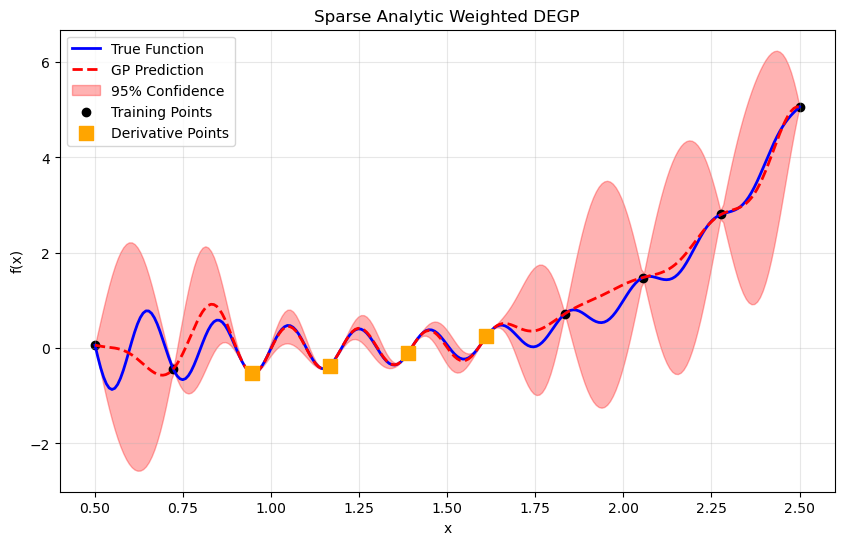

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(X_test, y_true, 'b-', label='True Function', linewidth=2)
plt.plot(X_test.flatten(), y_pred.flatten(), 'r--', label='GP Prediction', linewidth=2)
plt.fill_between(X_test.ravel(),
                 (y_pred.flatten() - 2*np.sqrt(y_cov)).ravel(),
                 (y_pred.flatten() + 2*np.sqrt(y_cov)).ravel(),
                 color='red', alpha=0.3, label='95% Confidence')
plt.scatter(X_train, y_function_values, color='black', label='Training Points')
plt.scatter(X_train[derivative_indices], y_function_values[derivative_indices],
            color='orange', s=100, marker='s', label='Derivative Points', zorder=5)
plt.title("Sparse Analytic Weighted DEGP")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

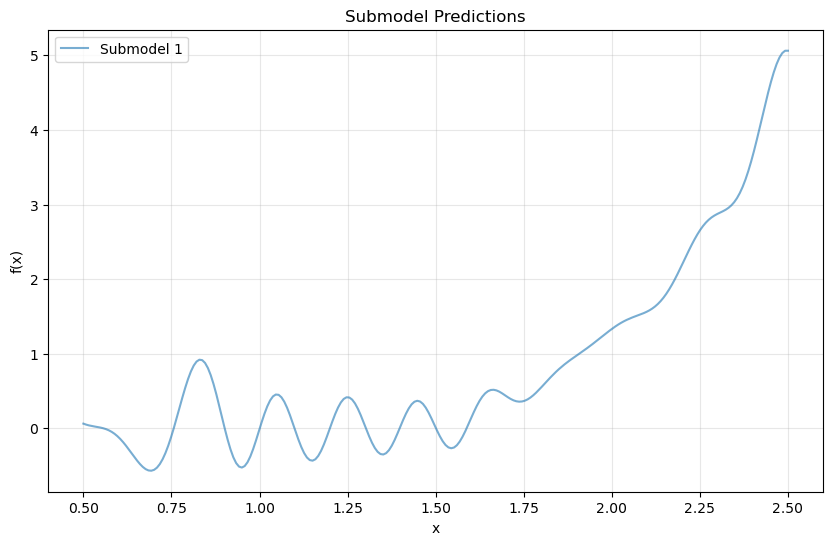

In [24]:
colors = plt.cm.tab10(np.linspace(0, 1, len(submodel_vals)))
plt.figure(figsize=(10, 6))
for i, color in enumerate(colors):
    plt.plot(X_test.flatten(), submodel_vals[i].flatten(), color=color,
             alpha=0.6, label=f'Submodel {i+1}')
plt.title("Submodel Predictions")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [25]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from wdegp.wdegp import wdegp
import utils

In [26]:
n_order = 2
n_bases = 1
lb_x = 0.5
ub_x = 2.5
num_points = 10
test_points = 250
kernel = "SE"
kernel_type = "anisotropic"
normalize = True
n_restart_optimizer = 15
swarm_size = 50
random_seed = 42

np.random.seed(random_seed)

In [27]:
x = sp.symbols('x')
f_sym = sp.sin(10 * sp.pi * x) / (2 * x) + (x - 1)**4

# Compute first and second derivatives symbolically
f1_sym = sp.diff(f_sym, x)
f2_sym = sp.diff(f_sym, x, 2)

# Convert to callable NumPy functions
f_fun = sp.lambdify(x, f_sym, "numpy")
f1_fun = sp.lambdify(x, f1_sym, "numpy")
f2_fun = sp.lambdify(x, f2_sym, "numpy")

In [28]:
# Generate all potential training points
X_all = np.linspace(lb_x, ub_x, num_points).reshape(-1, 1)

print("All available training points:")
for i, x in enumerate(X_all.ravel()):
    print(f"  Index {i}: x = {x:.4f}")

All available training points:
  Index 0: x = 0.5000
  Index 1: x = 0.7222
  Index 2: x = 0.9444
  Index 3: x = 1.1667
  Index 4: x = 1.3889
  Index 5: x = 1.6111
  Index 6: x = 1.8333
  Index 7: x = 2.0556
  Index 8: x = 2.2778
  Index 9: x = 2.5000


In [29]:
# Select non-contiguous training points for derivative observations
original_indices = [0, 2, 4, 6, 8]

print(f"\nOriginal training point indices where we want derivatives: {original_indices}")
print("\nSelected training points for derivatives:")
for i, orig_idx in enumerate(original_indices):
    print(f"  Original index {orig_idx}: x = {X_all[orig_idx, 0]:.4f}")


Original training point indices where we want derivatives: [0, 2, 4, 6, 8]

Selected training points for derivatives:
  Original index 0: x = 0.5000
  Original index 2: x = 0.9444
  Original index 4: x = 1.3889
  Original index 6: x = 1.8333
  Original index 8: x = 2.2778


In [30]:
# Reorder X_all so that selected points come first with sequential indices
# This allows us to use submodel_indices = [[0, 1, 2, 3, 4]]

# Create reordered array: selected points first, then unused points
X_train = np.vstack([X_all[original_indices],
                     X_all[[i for i in range(len(X_all)) if i not in original_indices]]])

print("\nReordered training array (X_train):")
print("  SELECTED points (with derivatives, indices 0-4):")
for i in range(len(original_indices)):
    orig_idx = original_indices[i]
    print(f"    X_train[{i}] = {X_train[i, 0]:.4f} (was X_all[{orig_idx}])")

print("  UNUSED points (function values only, indices 5-9):")
unused_original_indices = [i for i in range(len(X_all)) if i not in original_indices]
for i in range(len(original_indices), len(X_train)):
    orig_idx = unused_original_indices[i - len(original_indices)]
    print(f"    X_train[{i}] = {X_train[i, 0]:.4f} (was X_all[{orig_idx}])")

print(f"\n*** CRITICAL: X_train has ALL {len(X_train)} points, reordered so selected points have indices 0-4 ***")


Reordered training array (X_train):
  SELECTED points (with derivatives, indices 0-4):
    X_train[0] = 0.5000 (was X_all[0])
    X_train[1] = 0.9444 (was X_all[2])
    X_train[2] = 1.3889 (was X_all[4])
    X_train[3] = 1.8333 (was X_all[6])
    X_train[4] = 2.2778 (was X_all[8])
  UNUSED points (function values only, indices 5-9):
    X_train[5] = 0.7222 (was X_all[1])
    X_train[6] = 1.1667 (was X_all[3])
    X_train[7] = 1.6111 (was X_all[5])
    X_train[8] = 2.0556 (was X_all[7])
    X_train[9] = 2.5000 (was X_all[9])

*** CRITICAL: X_train has ALL 10 points, reordered so selected points have indices 0-4 ***


In [31]:
# CORRECT: Use sequential indices for the reordered training data
# Even though we selected original points [0,2,4,6,8], we now use [0,1,2,3,4]
# Create ONE submodel that uses derivatives at the first 5 points
submodel_indices = [[0, 1, 2, 3, 4]]  # Single submodel with derivatives at indices 0-4

# Derivative specs: full derivative set for this submodel
base_derivative_indices = utils.gen_OTI_indices(n_bases, n_order)
derivative_specs = [base_derivative_indices]  # One spec for one submodel

print(f"Number of submodels: {len(submodel_indices)}")
print(f"Submodel indices (sequential): {submodel_indices}")
print(f"Derivative types per submodel: {len(base_derivative_indices)}")

print("\n*** These indices reference positions in X_train (0-4 are selected points) ***")

Number of submodels: 1
Submodel indices (sequential): [[0, 1, 2, 3, 4]]
Derivative types per submodel: 2

*** These indices reference positions in X_train (0-4 are selected points) ***


In [32]:
# Compute function values at ALL reordered training points
y_function_values = f_fun(X_train.flatten()).reshape(-1, 1)

print("Function values at ALL reordered training points (X_train):")
for i, (x, y) in enumerate(zip(X_train.ravel(), y_function_values.ravel())):
    status = "SELECTED (with derivatives)" if i < len(original_indices) else "unused (function only)"
    print(f"  X_train[{i}] = {x:.4f}: f(x) = {y:.4f}  ({status})")

# Prepare submodel data with derivatives at the selected points only
# For this single submodel, we need derivatives at the first 5 points (indices 0-4)
derivative_indices = [0, 1, 2, 3, 4]  # First 5 indices in X_train

# Compute derivatives at selected points
d1_all = np.array([[f1_fun(X_train[idx, 0])] for idx in derivative_indices])
d2_all = np.array([[f2_fun(X_train[idx, 0])] for idx in derivative_indices])

print("\nFirst derivatives at SELECTED points (indices 0-4 in X_train):")
for i, d1_val in enumerate(d1_all):
    print(f"  d1(X_train[{i}]) = {d1_val[0]:.4f}")

print("\nSecond derivatives at SELECTED points (indices 0-4 in X_train):")
for i, d2_val in enumerate(d2_all):
    print(f"  d2(X_train[{i}]) = {d2_val[0]:.4f}")

# Single submodel data: [function values at ALL points, derivatives at selected points]
# y_function_values contains ALL function values from X_train (10 points, reordered)
# d1_all and d2_all contain derivatives only at first 5 points (indices 0-4)
submodel_data = [[y_function_values, d1_all, d2_all]]

print("\nCRITICAL: Submodel data structure")
print(f"  {len(submodel_data)} submodel (single submodel)")
print(f"  This submodel has {len(submodel_data[0])} elements:")
print(f"    - Element 0: Function values at ALL {len(y_function_values)} points in X_train")
print(f"    - Element 1: First derivatives at {len(d1_all)} points (indices 0-4)")
print(f"    - Element 2: Second derivatives at {len(d2_all)} points (indices 0-4)")

Function values at ALL reordered training points (X_train):
  X_train[0] = 0.5000: f(x) = 0.0625  (SELECTED (with derivatives))
  X_train[1] = 0.9444: f(x) = -0.5214  (SELECTED (with derivatives))
  X_train[2] = 1.3889: f(x) = -0.1003  (SELECTED (with derivatives))
  X_train[3] = 1.8333: f(x) = 0.7184  (SELECTED (with derivatives))
  X_train[4] = 2.2778: f(x) = 2.8069  (SELECTED (with derivatives))
  X_train[5] = 0.7222: f(x) = -0.4391  (unused (function only))
  X_train[6] = 1.1667: f(x) = -0.3704  (unused (function only))
  X_train[7] = 1.6111: f(x) = 0.2456  (unused (function only))
  X_train[8] = 2.0556: f(x) = 1.4810  (unused (function only))
  X_train[9] = 2.5000: f(x) = 5.0625  (unused (function only))

First derivatives at SELECTED points (indices 0-4 in X_train):
  d1(X_train[0]) = -31.9159
  d1(X_train[1]) = -2.3368
  d1(X_train[2]) = 10.9516
  d1(X_train[3]) = 6.4700
  d1(X_train[4]) = 3.0003

Second derivatives at SELECTED points (indices 0-4 in X_train):
  d2(X_train[0]) =

In [33]:
gp_model = wdegp(
    X_train,
    submodel_data,
    n_order,
    n_bases,
    submodel_indices,
    derivative_specs,
    normalize=normalize,
    kernel=kernel,
    kernel_type=kernel_type
)

In [34]:
params = gp_model.optimize_hyperparameters(
    optimizer='jade',
    pop_size = 100,
    n_generations = 15,
    local_opt_every = None,
    debug = False
    )
print("Optimized hyperparameters:", params)

Optimized hyperparameters: [  0.83683935  -0.05986268 -11.05288966]


In [35]:
X_test = np.linspace(lb_x, ub_x, test_points).reshape(-1, 1)
y_pred, y_cov, submodel_vals, submodel_cov = gp_model.predict(
    X_test, params, calc_cov=True, return_submodels=True
)
y_true = f_fun(X_test.flatten())
nrmse = np.sqrt(np.mean((y_true - y_pred.flatten())**2)) / (y_true.max() - y_true.min())
print(f"NRMSE: {nrmse:.6f}")

NRMSE: 0.103310


In [36]:
# ------------------------------------------------------------
# Verify function value interpolation at all reordered training points
# ------------------------------------------------------------
y_pred_train = gp_model.predict(X_train, params, calc_cov=False)

print("Function value interpolation errors (reordered X_train):")
print("=" * 80)
for i in range(num_points):
    error_abs = abs(y_pred_train[0, i] - y_function_values[i, 0])
    error_rel = error_abs / abs(y_function_values[i, 0]) if y_function_values[i, 0] != 0 else error_abs
    print(f"X_train[{i}] (x={X_train[i, 0]:.4f}): Abs Error = {error_abs:.2e}, Rel Error = {error_rel:.2e}")

max_func_error = np.max(np.abs(y_pred_train.flatten() - y_function_values.flatten()))
print(f"\nMaximum absolute function value error: {max_func_error:.2e}")

# ------------------------------------------------------------
# Verify derivative interpolation at reordered derivative points (indices 0-4)
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("Derivative interpolation verification:")
print("=" * 80)
print(f"Checking derivatives at reordered indices 0-4 (contiguous derivative points)")
print(f"These correspond to original indices: {original_indices}")
print("Note: Sparse formulation uses one global model with all training points")
print("      and derivatives enforced only at indices 0-4")
print("=" * 80)

# Use small perturbation for finite differences
h = 1e-6

for i in range(len(original_indices)):
    x_point = X_train[i, 0]

    # Get predictions at perturbed points
    X_plus = np.array([[x_point + h]])
    X_minus = np.array([[x_point - h]])
    X_center = X_train[i].reshape(1, -1)

    # Get predictions from the global model
    y_plus = gp_model.predict(X_plus, params, calc_cov=False)
    y_minus = gp_model.predict(X_minus, params, calc_cov=False)
    y_center = gp_model.predict(X_center, params, calc_cov=False)

    # First derivative via central difference
    fd_first_deriv = (y_plus[0, 0] - y_minus[0, 0]) / (2 * h)
    analytic_first_deriv = d1_all[i, 0]
    error_first_abs = abs(fd_first_deriv - analytic_first_deriv)
    error_first_rel = error_first_abs / abs(analytic_first_deriv) if analytic_first_deriv != 0 else error_first_abs

    # Second derivative via central difference
    fd_second_deriv = (y_plus[0, 0] - 2 * y_center[0, 0] + y_minus[0, 0]) / (h ** 2)
    analytic_second_deriv = d2_all[i, 0]
    error_second_abs = abs(fd_second_deriv - analytic_second_deriv)
    error_second_rel = error_second_abs / abs(analytic_second_deriv) if analytic_second_deriv != 0 else error_second_abs

    orig_idx = original_indices[i]
    print(f"\nX_train[{i}] (was X_all[{orig_idx}], x = {x_point:.3f}):")
    print(f"  1st derivative - Analytic: {analytic_first_deriv:+.6f}, FD: {fd_first_deriv:+.6f}")
    print(f"                   Abs Error: {error_first_abs:.2e}, Rel Error: {error_first_rel:.2e}")
    print(f"  2nd derivative - Analytic: {analytic_second_deriv:+.6f}, FD: {fd_second_deriv:+.6f}")
    print(f"                   Abs Error: {error_second_abs:.2e}, Rel Error: {error_second_rel:.2e}")

# ------------------------------------------------------------
# Show that points without derivatives (indices 5-9) are NOT checked
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("Points without derivative constraints (indices 5-9):")
print("=" * 80)
unused_original_indices = [i for i in range(len(X_all)) if i not in original_indices]
for j, orig_idx in enumerate(unused_original_indices):
    new_idx = len(original_indices) + j
    x_point = X_train[new_idx, 0]
    print(f"X_train[{new_idx}] (was X_all[{orig_idx}], x = {x_point:.3f}): "
          f"Only function value enforced, no derivative constraints")

print("\n" + "=" * 80)
print("Interpolation verification complete!")
print("Relative errors should be close to machine precision (< 1e-6)")
print("\n" + "=" * 80)
print("SUMMARY:")
print(f"  - Function values: enforced at all {num_points} training points")
print(f"  - First derivatives: verified at reordered indices 0-4")
print(f"  - Second derivatives: verified at reordered indices 0-4")
print(f"  - Reordered indices 0-4 correspond to original indices: {original_indices}")
print(f"  - Sparse formulation: ONE global model with derivatives at contiguous indices")
print(f"  - Verification method: Finite differences on the global model")
print("=" * 80)

Function value interpolation errors (reordered X_train):
X_train[0] (x=0.5000): Abs Error = 5.55e-17, Rel Error = 8.88e-16
X_train[1] (x=0.9444): Abs Error = 1.11e-16, Rel Error = 2.13e-16
X_train[2] (x=1.3889): Abs Error = 8.33e-17, Rel Error = 8.31e-16
X_train[3] (x=1.8333): Abs Error = 3.33e-16, Rel Error = 4.64e-16
X_train[4] (x=2.2778): Abs Error = 8.88e-16, Rel Error = 3.16e-16
X_train[5] (x=0.7222): Abs Error = 1.67e-16, Rel Error = 3.79e-16
X_train[6] (x=1.1667): Abs Error = 4.44e-16, Rel Error = 1.20e-15
X_train[7] (x=1.6111): Abs Error = 1.67e-16, Rel Error = 6.78e-16
X_train[8] (x=2.0556): Abs Error = 4.44e-16, Rel Error = 3.00e-16
X_train[9] (x=2.5000): Abs Error = 0.00e+00, Rel Error = 0.00e+00

Maximum absolute function value error: 8.88e-16

Derivative interpolation verification:
Checking derivatives at reordered indices 0-4 (contiguous derivative points)
These correspond to original indices: [0, 2, 4, 6, 8]
Note: Sparse formulation uses one global model with all trainin


X_train[0] (was X_all[0], x = 0.500):
  1st derivative - Analytic: -31.915927, FD: -31.915927
                   Abs Error: 1.39e-09, Rel Error: 4.35e-11
  2nd derivative - Analytic: +128.663706, FD: +128.658861
                   Abs Error: 4.84e-03, Rel Error: 3.77e-05

X_train[1] (was X_all[2], x = 0.944):
  1st derivative - Analytic: -2.336758, FD: -2.336758
                   Abs Error: 2.09e-10, Rel Error: 8.94e-11
  2nd derivative - Analytic: +519.554404, FD: +519.554177
                   Abs Error: 2.27e-04, Rel Error: 4.36e-07

X_train[2] (was X_all[4], x = 1.389):
  1st derivative - Analytic: +10.951579, FD: +10.951579
                   Abs Error: 1.27e-09, Rel Error: 1.16e-10
  2nd derivative - Analytic: +107.905034, FD: +107.905018
                   Abs Error: 1.53e-05, Rel Error: 1.42e-07

X_train[3] (was X_all[6], x = 1.833):
  1st derivative - Analytic: +6.469975, FD: +6.469975
                   Abs Error: 5.82e-10, Rel Error: 9.00e-11
  2nd derivative - Analytic: -

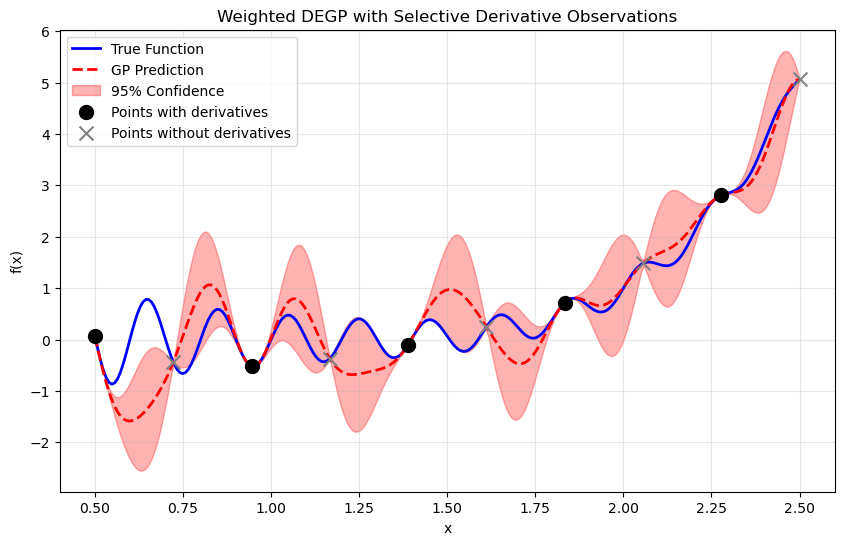

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(X_test, y_true, 'b-', label='True Function', linewidth=2)
plt.plot(X_test.flatten(), y_pred.flatten(), 'r--', label='GP Prediction', linewidth=2)
plt.fill_between(X_test.ravel(),
                 (y_pred.flatten() - 2*np.sqrt(y_cov)).ravel(),
                 (y_pred.flatten() + 2*np.sqrt(y_cov)).ravel(),
                 color='red', alpha=0.3, label='95% Confidence')

# Show selected training points (used in model with derivatives)
plt.scatter(X_train[:len(original_indices)],
            f_fun(X_train[:len(original_indices), 0].flatten()).reshape(-1, 1),
            color='black', s=100, label='Points with derivatives', zorder=5)

# Show unused training points (function values only, no derivatives)
plt.scatter(X_train[len(original_indices):],
            f_fun(X_train[len(original_indices):, 0].flatten()).reshape(-1, 1),
            color='gray', s=100, marker='x',
            label='Points without derivatives', zorder=5)

plt.title("Weighted DEGP with Selective Derivative Observations")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [38]:
print("=" * 70)
print("INDEX MAPPING SUMMARY")
print("=" * 70)
print("\nOriginal Data (X_all) --> Reordered Data (X_train):")
print("-" * 70)

# Show mapping for selected points
print("SELECTED points (with derivatives):")
for i in range(len(original_indices)):
    orig_idx = original_indices[i]
    print(f"  X_all[{orig_idx}] = {X_all[orig_idx,0]:.4f}  -->  X_train[{i}] = {X_train[i,0]:.4f}")

# Show mapping for unused points
print("\nUNUSED points (function values only):")
unused_original_indices = [i for i in range(len(X_all)) if i not in original_indices]
for j, orig_idx in enumerate(unused_original_indices):
    new_idx = len(original_indices) + j
    print(f"  X_all[{orig_idx}] = {X_all[orig_idx,0]:.4f}  -->  X_train[{new_idx}] = {X_train[new_idx,0]:.4f}")

print("\nSubmodel Indices:")
print("-" * 70)
print(f"  submodel_indices = {submodel_indices}")
print(f"  These reference the FIRST 5 positions in reordered X_train")
print(f"  Which correspond to original indices: {original_indices}")
print("=" * 70)

INDEX MAPPING SUMMARY

Original Data (X_all) --> Reordered Data (X_train):
----------------------------------------------------------------------
SELECTED points (with derivatives):
  X_all[0] = 0.5000  -->  X_train[0] = 0.5000
  X_all[2] = 0.9444  -->  X_train[1] = 0.9444
  X_all[4] = 1.3889  -->  X_train[2] = 1.3889
  X_all[6] = 1.8333  -->  X_train[3] = 1.8333
  X_all[8] = 2.2778  -->  X_train[4] = 2.2778

UNUSED points (function values only):
  X_all[1] = 0.7222  -->  X_train[5] = 0.7222
  X_all[3] = 1.1667  -->  X_train[6] = 1.1667
  X_all[5] = 1.6111  -->  X_train[7] = 1.6111
  X_all[7] = 2.0556  -->  X_train[8] = 2.0556
  X_all[9] = 2.5000  -->  X_train[9] = 2.5000

Submodel Indices:
----------------------------------------------------------------------
  submodel_indices = [[0, 1, 2, 3, 4]]
  These reference the FIRST 5 positions in reordered X_train
  Which correspond to original indices: [0, 2, 4, 6, 8]


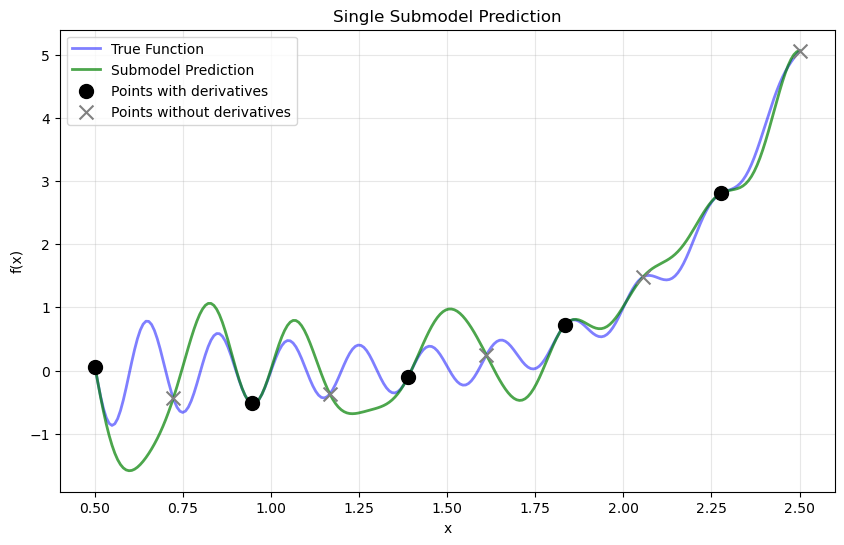

In [39]:
plt.figure(figsize=(10, 6))
plt.plot(X_test, y_true, 'b-', label='True Function', linewidth=2, alpha=0.5)
plt.plot(X_test.flatten(), submodel_vals[0].flatten(), 'g-',
         label='Submodel Prediction', linewidth=2, alpha=0.7)
plt.scatter(X_train[:len(original_indices)],
            f_fun(X_train[:len(original_indices), 0].flatten()).reshape(-1, 1),
            color='black', s=100, label='Points with derivatives', zorder=5)
plt.scatter(X_train[len(original_indices):],
            f_fun(X_train[len(original_indices):, 0].flatten()).reshape(-1, 1),
            color='gray', s=100, marker='x', label='Points without derivatives', zorder=5)
plt.title("Single Submodel Prediction")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [40]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from wdegp.wdegp import wdegp
import utils

In [41]:
n_order = 2
n_bases = 1
lb_x = 0.5
ub_x = 2.5
num_points = 10
test_points = 250
kernel = "SE"
kernel_type = "anisotropic"
normalize = True
n_restart_optimizer = 15
swarm_size = 50
random_seed = 42

np.random.seed(random_seed)

In [42]:
x = sp.symbols('x')
f_sym = sp.sin(10 * sp.pi * x) / (2 * x) + (x - 1)**4

# Compute first and second derivatives symbolically
f1_sym = sp.diff(f_sym, x)
f2_sym = sp.diff(f_sym, x, 2)

# Convert to callable NumPy functions
f_fun = sp.lambdify(x, f_sym, "numpy")
f1_fun = sp.lambdify(x, f1_sym, "numpy")
f2_fun = sp.lambdify(x, f2_sym, "numpy")

In [43]:
# Generate all training points
X_all = np.linspace(lb_x, ub_x, num_points).reshape(-1, 1)

print("All available training points:")
for i, x in enumerate(X_all.ravel()):
    print(f"  Index {i}: x = {x:.4f}")

All available training points:
  Index 0: x = 0.5000
  Index 1: x = 0.7222
  Index 2: x = 0.9444
  Index 3: x = 1.1667
  Index 4: x = 1.3889
  Index 5: x = 1.6111
  Index 6: x = 1.8333
  Index 7: x = 2.0556
  Index 8: x = 2.2778
  Index 9: x = 2.5000


In [44]:
# Submodel 1: uses points [0,2,4,6,8]
# Submodel 2: uses points [1,3,5,7,9]
submodel1_original_indices = [0, 2, 4, 6, 8]
submodel2_original_indices = [1, 3, 5, 7, 9]

print(f"Submodel 1 will use derivatives at original indices: {submodel1_original_indices}")
print(f"Submodel 2 will use derivatives at original indices: {submodel2_original_indices}")

Submodel 1 will use derivatives at original indices: [0, 2, 4, 6, 8]
Submodel 2 will use derivatives at original indices: [1, 3, 5, 7, 9]


In [45]:
# Reorder so submodel 1 points come first (indices 0-4),
# then submodel 2 points (indices 5-9)
X_train = np.vstack([X_all[submodel1_original_indices],
                     X_all[submodel2_original_indices]])

print("\nReordered training array (X_train):")
print("  Submodel 1 points (indices 0-4):")
for i in range(len(submodel1_original_indices)):
    orig_idx = submodel1_original_indices[i]
    print(f"    X_train[{i}] = {X_train[i, 0]:.4f} (was X_all[{orig_idx}])")

print("  Submodel 2 points (indices 5-9):")
for i in range(len(submodel1_original_indices), len(X_train)):
    orig_idx = submodel2_original_indices[i - len(submodel1_original_indices)]
    print(f"    X_train[{i}] = {X_train[i, 0]:.4f} (was X_all[{orig_idx}])")

print(f"\n*** X_train has ALL {len(X_train)} points, reordered for contiguous submodel indices ***")


Reordered training array (X_train):
  Submodel 1 points (indices 0-4):
    X_train[0] = 0.5000 (was X_all[0])
    X_train[1] = 0.9444 (was X_all[2])
    X_train[2] = 1.3889 (was X_all[4])
    X_train[3] = 1.8333 (was X_all[6])
    X_train[4] = 2.2778 (was X_all[8])
  Submodel 2 points (indices 5-9):
    X_train[5] = 0.7222 (was X_all[1])
    X_train[6] = 1.1667 (was X_all[3])
    X_train[7] = 1.6111 (was X_all[5])
    X_train[8] = 2.0556 (was X_all[7])
    X_train[9] = 2.5000 (was X_all[9])

*** X_train has ALL 10 points, reordered for contiguous submodel indices ***


In [46]:
# Submodel 1: references indices 0-4 in X_train
# Submodel 2: references indices 5-9 in X_train
submodel_indices = [[0, 1, 2, 3, 4],    # Submodel 1
                    [5, 6, 7, 8, 9]]    # Submodel 2

# Derivative specs: full derivative set for each submodel
base_derivative_indices = utils.gen_OTI_indices(n_bases, n_order)
derivative_specs = [base_derivative_indices, base_derivative_indices]

print(f"Number of submodels: {len(submodel_indices)}")
print(f"Submodel 1 indices: {submodel_indices[0]}")
print(f"Submodel 2 indices: {submodel_indices[1]}")
print(f"Derivative types per submodel: {len(base_derivative_indices)}")

Number of submodels: 2
Submodel 1 indices: [0, 1, 2, 3, 4]
Submodel 2 indices: [5, 6, 7, 8, 9]
Derivative types per submodel: 2


In [47]:
# Function values at ALL reordered training points
y_function_values = f_fun(X_train.flatten()).reshape(-1, 1)

print("Function values at ALL reordered training points:")
for i, (x, y) in enumerate(zip(X_train.ravel(), y_function_values.ravel())):
    submodel = "Submodel 1" if i < 5 else "Submodel 2"
    print(f"  X_train[{i}] = {x:.4f}: f(x) = {y:.4f}  ({submodel})")

# Submodel 1: derivatives at indices 0-4
print("\nSubmodel 1 - Derivatives at indices 0-4:")
submodel1_derivative_indices = [0, 1, 2, 3, 4]
d1_submodel1 = np.array([[f1_fun(X_train[idx, 0])] for idx in submodel1_derivative_indices])
d2_submodel1 = np.array([[f2_fun(X_train[idx, 0])] for idx in submodel1_derivative_indices])

for i in range(len(d1_submodel1)):
    print(f"  d1(X_train[{i}]) = {d1_submodel1[i, 0]:.4f}")

# Submodel 2: derivatives at indices 5-9
print("\nSubmodel 2 - Derivatives at indices 5-9:")
submodel2_derivative_indices = [5, 6, 7, 8, 9]
d1_submodel2 = np.array([[f1_fun(X_train[idx, 0])] for idx in submodel2_derivative_indices])
d2_submodel2 = np.array([[f2_fun(X_train[idx, 0])] for idx in submodel2_derivative_indices])

for i, idx in enumerate(submodel2_derivative_indices):
    print(f"  d1(X_train[{idx}]) = {d1_submodel2[i, 0]:.4f}")

# Prepare submodel data
# Each submodel gets: [function values at ALL points, derivatives at its points]
submodel_data = [
    [y_function_values, d1_submodel1, d2_submodel1],  # Submodel 1
    [y_function_values, d1_submodel2, d2_submodel2]   # Submodel 2
]

print("\nCRITICAL: Submodel data structure")
print(f"  {len(submodel_data)} submodels")
print(f"  Each submodel has {len(submodel_data[0])} elements:")
print(f"    - Element 0: Function values at ALL {len(y_function_values)} points")
print(f"    - Element 1: First derivatives at submodel's 5 points")
print(f"    - Element 2: Second derivatives at submodel's 5 points")

Function values at ALL reordered training points:
  X_train[0] = 0.5000: f(x) = 0.0625  (Submodel 1)
  X_train[1] = 0.9444: f(x) = -0.5214  (Submodel 1)
  X_train[2] = 1.3889: f(x) = -0.1003  (Submodel 1)
  X_train[3] = 1.8333: f(x) = 0.7184  (Submodel 1)
  X_train[4] = 2.2778: f(x) = 2.8069  (Submodel 1)
  X_train[5] = 0.7222: f(x) = -0.4391  (Submodel 2)
  X_train[6] = 1.1667: f(x) = -0.3704  (Submodel 2)
  X_train[7] = 1.6111: f(x) = 0.2456  (Submodel 2)
  X_train[8] = 2.0556: f(x) = 1.4810  (Submodel 2)
  X_train[9] = 2.5000: f(x) = 5.0625  (Submodel 2)

Submodel 1 - Derivatives at indices 0-4:
  d1(X_train[0]) = -31.9159
  d1(X_train[1]) = -2.3368
  d1(X_train[2]) = 10.9516
  d1(X_train[3]) = 6.4700
  d1(X_train[4]) = 3.0003

Submodel 2 - Derivatives at indices 5-9:
  d1(X_train[5]) = -16.1306
  d1(X_train[6]) = 7.0686
  d1(X_train[7]) = 10.0088
  d1(X_train[8]) = 3.2609
  d1(X_train[9]) = 7.2168

CRITICAL: Submodel data structure
  2 submodels
  Each submodel has 3 elements:
    

In [48]:
gp_model = wdegp(
    X_train,
    submodel_data,
    n_order,
    n_bases,
    submodel_indices,
    derivative_specs,
    normalize=normalize,
    kernel=kernel,
    kernel_type=kernel_type
)

In [49]:
params = gp_model.optimize_hyperparameters(
    optimizer='jade',
    pop_size = 100,
    n_generations = 15,
    local_opt_every = None,
    debug = False
    )
print("Optimized hyperparameters:", params)

Optimized hyperparameters: [ 8.25433193e-01  5.99618270e-03 -1.51722455e+01]


In [50]:
X_test = np.linspace(lb_x, ub_x, test_points).reshape(-1, 1)
y_pred, y_cov, submodel_vals, submodel_cov = gp_model.predict(
    X_test, params, calc_cov=True, return_submodels=True
)
y_true = f_fun(X_test.flatten())
nrmse = np.sqrt(np.mean((y_true - y_pred.flatten())**2)) / (y_true.max() - y_true.min())
print(f"NRMSE: {nrmse:.6f}")

NRMSE: 0.009653


In [51]:
# ------------------------------------------------------------
# Verify function value interpolation at all reordered training points
# ------------------------------------------------------------
y_pred_train = gp_model.predict(X_train, params, calc_cov=False)

print("Function value interpolation errors (reordered X_train):")
print("=" * 80)
for i in range(num_points):
    error_abs = abs(y_pred_train[0, i] - y_function_values[i, 0])
    error_rel = error_abs / abs(y_function_values[i, 0]) if y_function_values[i, 0] != 0 else error_abs
    submodel_id = 1 if i < 5 else 2
    print(f"X_train[{i}] (SM{submodel_id}, x={X_train[i, 0]:.4f}): Abs Error = {error_abs:.2e}, Rel Error = {error_rel:.2e}")

max_func_error = np.max(np.abs(y_pred_train.flatten() - y_function_values.flatten()))
print(f"\nMaximum absolute function value error: {max_func_error:.2e}")

# ------------------------------------------------------------
# Verify derivative interpolation for Submodel 1 (indices 0-4)
# on the individual submodel (before weighted combination)
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("Derivative interpolation verification - SUBMODEL 1:")
print("=" * 80)
print(f"Checking derivatives at reordered indices 0-4")
print(f"These correspond to original indices: {submodel1_original_indices}")
print("Note: Verifying derivatives on individual submodel 1 before weighted combination")
print("      to avoid numerical instabilities from the weighting function")
print("=" * 80)

# Use small perturbation for finite differences
h = 1e-6

for i in range(len(submodel1_original_indices)):
    x_point = X_train[i, 0]

    # Get predictions at perturbed points from individual submodels
    X_plus = np.array([[x_point + h]])
    X_minus = np.array([[x_point - h]])
    X_center = X_train[i].reshape(1, -1)

    # Get predictions from individual submodels (not weighted combination)
    _, submodel_vals_plus = gp_model.predict(X_plus, params, calc_cov=False, return_submodels=True)
    _, submodel_vals_minus = gp_model.predict(X_minus, params, calc_cov=False, return_submodels=True)
    _, submodel_vals_center = gp_model.predict(X_center, params, calc_cov=False, return_submodels=True)

    # First derivative via central difference on submodel 1 (index 0)
    fd_first_deriv = (submodel_vals_plus[0][0, 0] - submodel_vals_minus[0][0, 0]) / (2 * h)
    analytic_first_deriv = d1_submodel1[i, 0]
    error_first_abs = abs(fd_first_deriv - analytic_first_deriv)
    error_first_rel = error_first_abs / abs(analytic_first_deriv) if analytic_first_deriv != 0 else error_first_abs

    # Second derivative via central difference on submodel 1 (index 0)
    fd_second_deriv = (submodel_vals_plus[0][0, 0] - 2 * submodel_vals_center[0][0, 0] + submodel_vals_minus[0][0, 0]) / (h ** 2)
    analytic_second_deriv = d2_submodel1[i, 0]
    error_second_abs = abs(fd_second_deriv - analytic_second_deriv)
    error_second_rel = error_second_abs / abs(analytic_second_deriv) if analytic_second_deriv != 0 else error_second_abs

    orig_idx = submodel1_original_indices[i]
    print(f"\nSubmodel 1 at X_train[{i}] (was X_all[{orig_idx}], x = {x_point:.3f}):")
    print(f"  1st derivative - Analytic: {analytic_first_deriv:+.6f}, FD: {fd_first_deriv:+.6f}")
    print(f"                   Abs Error: {error_first_abs:.2e}, Rel Error: {error_first_rel:.2e}")
    print(f"  2nd derivative - Analytic: {analytic_second_deriv:+.6f}, FD: {fd_second_deriv:+.6f}")
    print(f"                   Abs Error: {error_second_abs:.2e}, Rel Error: {error_second_rel:.2e}")

# ------------------------------------------------------------
# Verify derivative interpolation for Submodel 2 (indices 5-9)
# on the individual submodel (before weighted combination)
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("Derivative interpolation verification - SUBMODEL 2:")
print("=" * 80)
print(f"Checking derivatives at reordered indices 5-9")
print(f"These correspond to original indices: {submodel2_original_indices}")
print("Note: Verifying derivatives on individual submodel 2 before weighted combination")
print("      to avoid numerical instabilities from the weighting function")
print("=" * 80)

for i in range(len(submodel2_original_indices)):
    train_idx = len(submodel1_original_indices) + i  # Offset by submodel 1 size
    x_point = X_train[train_idx, 0]

    # Get predictions at perturbed points from individual submodels
    X_plus = np.array([[x_point + h]])
    X_minus = np.array([[x_point - h]])
    X_center = X_train[train_idx].reshape(1, -1)

    # Get predictions from individual submodels (not weighted combination)
    _, submodel_vals_plus = gp_model.predict(X_plus, params, calc_cov=False, return_submodels=True)
    _, submodel_vals_minus = gp_model.predict(X_minus, params, calc_cov=False, return_submodels=True)
    _, submodel_vals_center = gp_model.predict(X_center, params, calc_cov=False, return_submodels=True)

    # First derivative via central difference on submodel 2 (index 1)
    fd_first_deriv = (submodel_vals_plus[1][0, 0] - submodel_vals_minus[1][0, 0]) / (2 * h)
    analytic_first_deriv = d1_submodel2[i, 0]
    error_first_abs = abs(fd_first_deriv - analytic_first_deriv)
    error_first_rel = error_first_abs / abs(analytic_first_deriv) if analytic_first_deriv != 0 else error_first_abs

    # Second derivative via central difference on submodel 2 (index 1)
    fd_second_deriv = (submodel_vals_plus[1][0, 0] - 2 * submodel_vals_center[1][0, 0] + submodel_vals_minus[1][0, 0]) / (h ** 2)
    analytic_second_deriv = d2_submodel2[i, 0]
    error_second_abs = abs(fd_second_deriv - analytic_second_deriv)
    error_second_rel = error_second_abs / abs(analytic_second_deriv) if analytic_second_deriv != 0 else error_second_abs

    orig_idx = submodel2_original_indices[i]
    print(f"\nSubmodel 2 at X_train[{train_idx}] (was X_all[{orig_idx}], x = {x_point:.3f}):")
    print(f"  1st derivative - Analytic: {analytic_first_deriv:+.6f}, FD: {fd_first_deriv:+.6f}")
    print(f"                   Abs Error: {error_first_abs:.2e}, Rel Error: {error_first_rel:.2e}")
    print(f"  2nd derivative - Analytic: {analytic_second_deriv:+.6f}, FD: {fd_second_deriv:+.6f}")
    print(f"                   Abs Error: {error_second_abs:.2e}, Rel Error: {error_second_rel:.2e}")

print("\n" + "=" * 80)
print("Interpolation verification complete!")
print("Relative errors should be close to machine precision (< 1e-6)")
print("\n" + "=" * 80)
print("SUMMARY:")
print(f"  - Function values: enforced at ALL {num_points} training points")
print(f"  - Submodel 1 first derivatives: verified at X_train[0-4]")
print(f"    (original indices: {submodel1_original_indices})")
print(f"  - Submodel 1 second derivatives: verified at X_train[0-4]")
print(f"  - Submodel 2 first derivatives: verified at X_train[5-9]")
print(f"    (original indices: {submodel2_original_indices})")
print(f"  - Submodel 2 second derivatives: verified at X_train[5-9]")
print(f"  - Total submodels: 2 (each with its own derivative observations)")
print(f"  - Verification method: Finite differences on individual submodels before weighting")
print("=" * 80)

Function value interpolation errors (reordered X_train):
X_train[0] (SM1, x=0.5000): Abs Error = 5.55e-17, Rel Error = 8.88e-16
X_train[1] (SM1, x=0.9444): Abs Error = 1.11e-16, Rel Error = 2.13e-16
X_train[2] (SM1, x=1.3889): Abs Error = 2.50e-16, Rel Error = 2.49e-15
X_train[3] (SM1, x=1.8333): Abs Error = 0.00e+00, Rel Error = 0.00e+00
X_train[4] (SM1, x=2.2778): Abs Error = 4.44e-16, Rel Error = 1.58e-16
X_train[5] (SM2, x=0.7222): Abs Error = 5.55e-17, Rel Error = 1.26e-16
X_train[6] (SM2, x=1.1667): Abs Error = 0.00e+00, Rel Error = 0.00e+00
X_train[7] (SM2, x=1.6111): Abs Error = 3.05e-16, Rel Error = 1.24e-15
X_train[8] (SM2, x=2.0556): Abs Error = 0.00e+00, Rel Error = 0.00e+00
X_train[9] (SM2, x=2.5000): Abs Error = 8.88e-16, Rel Error = 1.75e-16

Maximum absolute function value error: 8.88e-16

Derivative interpolation verification - SUBMODEL 1:
Checking derivatives at reordered indices 0-4
These correspond to original indices: [0, 2, 4, 6, 8]
Note: Verifying derivatives on 

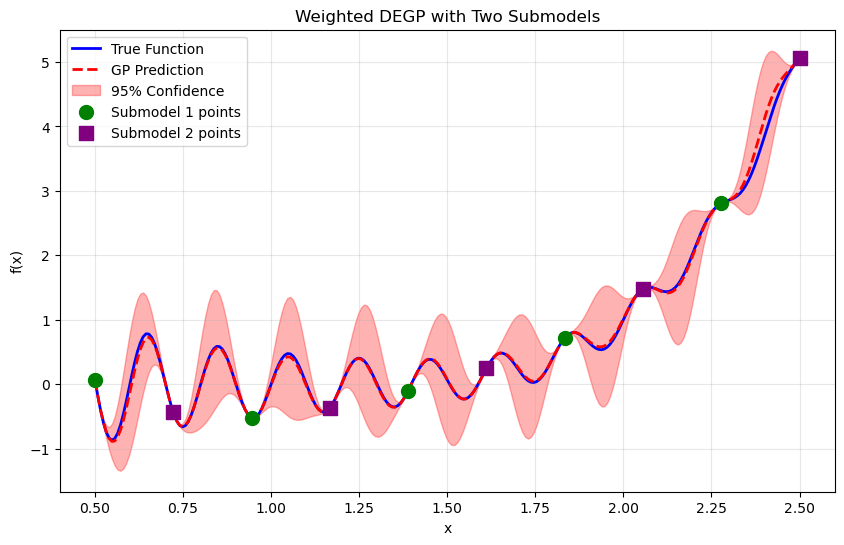

In [52]:
plt.figure(figsize=(10, 6))
plt.plot(X_test, y_true, 'b-', label='True Function', linewidth=2)
plt.plot(X_test.flatten(), y_pred.flatten(), 'r--', label='GP Prediction', linewidth=2)
plt.fill_between(X_test.ravel(),
                 (y_pred.flatten() - 2*np.sqrt(y_cov)).ravel(),
                 (y_pred.flatten() + 2*np.sqrt(y_cov)).ravel(),
                 color='red', alpha=0.3, label='95% Confidence')

# Show submodel 1 points
plt.scatter(X_train[:5],
            f_fun(X_train[:5, 0].flatten()).reshape(-1, 1),
            color='green', s=100, marker='o', label='Submodel 1 points', zorder=5)

# Show submodel 2 points
plt.scatter(X_train[5:],
            f_fun(X_train[5:, 0].flatten()).reshape(-1, 1),
            color='purple', s=100, marker='s',
            label='Submodel 2 points', zorder=5)

plt.title("Weighted DEGP with Two Submodels")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [53]:
print("=" * 70)
print("INDEX MAPPING SUMMARY")
print("=" * 70)
print("\nOriginal Data (X_all) --> Reordered Data (X_train):")
print("-" * 70)

print("Submodel 1 points:")
for i in range(len(submodel1_original_indices)):
    orig_idx = submodel1_original_indices[i]
    print(f"  X_all[{orig_idx}] = {X_all[orig_idx,0]:.4f}  -->  X_train[{i}] = {X_train[i,0]:.4f}")

print("\nSubmodel 2 points:")
for i, orig_idx in enumerate(submodel2_original_indices):
    new_idx = len(submodel1_original_indices) + i
    print(f"  X_all[{orig_idx}] = {X_all[orig_idx,0]:.4f}  -->  X_train[{new_idx}] = {X_train[new_idx,0]:.4f}")

print("\nSubmodel Indices:")
print("-" * 70)
print(f"  Submodel 1: {submodel_indices[0]} (original indices: {submodel1_original_indices})")
print(f"  Submodel 2: {submodel_indices[1]} (original indices: {submodel2_original_indices})")
print("=" * 70)

INDEX MAPPING SUMMARY

Original Data (X_all) --> Reordered Data (X_train):
----------------------------------------------------------------------
Submodel 1 points:
  X_all[0] = 0.5000  -->  X_train[0] = 0.5000
  X_all[2] = 0.9444  -->  X_train[1] = 0.9444
  X_all[4] = 1.3889  -->  X_train[2] = 1.3889
  X_all[6] = 1.8333  -->  X_train[3] = 1.8333
  X_all[8] = 2.2778  -->  X_train[4] = 2.2778

Submodel 2 points:
  X_all[1] = 0.7222  -->  X_train[5] = 0.7222
  X_all[3] = 1.1667  -->  X_train[6] = 1.1667
  X_all[5] = 1.6111  -->  X_train[7] = 1.6111
  X_all[7] = 2.0556  -->  X_train[8] = 2.0556
  X_all[9] = 2.5000  -->  X_train[9] = 2.5000

Submodel Indices:
----------------------------------------------------------------------
  Submodel 1: [0, 1, 2, 3, 4] (original indices: [0, 2, 4, 6, 8])
  Submodel 2: [5, 6, 7, 8, 9] (original indices: [1, 3, 5, 7, 9])


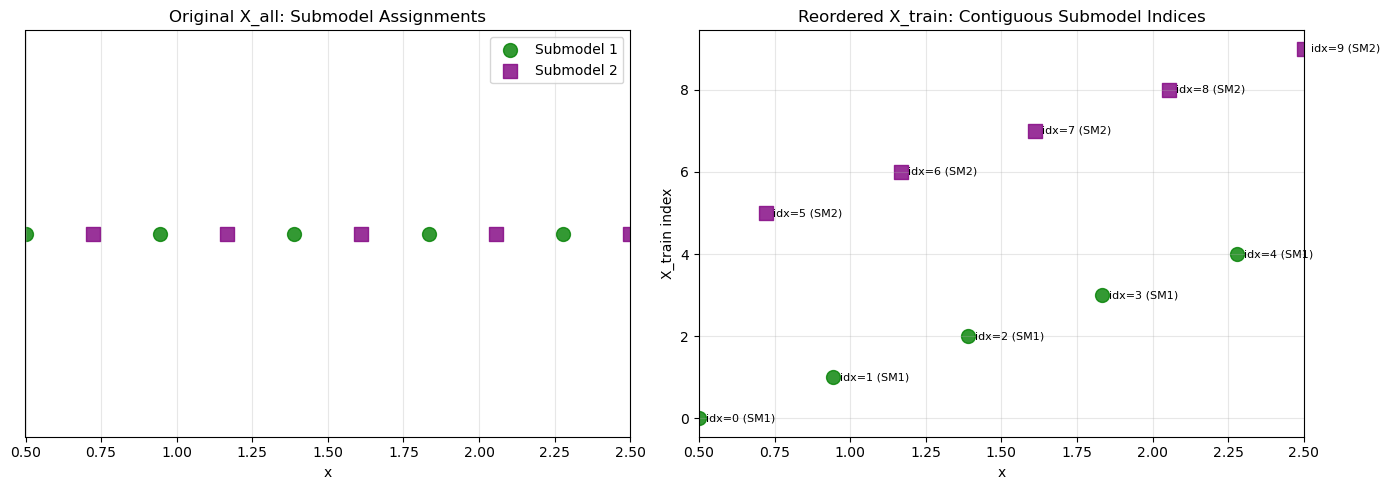

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Original X_all with submodel assignments
axes[0].scatter(X_all[submodel1_original_indices],
                np.zeros(len(submodel1_original_indices)),
                color='green', s=100, alpha=0.8, marker='o', label='Submodel 1')
axes[0].scatter(X_all[submodel2_original_indices],
                np.zeros(len(submodel2_original_indices)),
                color='purple', s=100, alpha=0.8, marker='s', label='Submodel 2')
axes[0].set_xlim(lb_x, ub_x)
axes[0].set_ylim(-0.5, 0.5)
axes[0].set_xlabel('x')
axes[0].set_title('Original X_all: Submodel Assignments')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_yticks([])

# Right: Reordered X_train
colors = ['green']*5 + ['purple']*5
markers = ['o']*5 + ['s']*5
for i, (x, color, marker) in enumerate(zip(X_train.ravel(), colors, markers)):
    axes[1].scatter(x, i, c=color, s=100, alpha=0.8, marker=marker)
    submodel = "SM1" if i < 5 else "SM2"
    axes[1].text(x, i, f'  idx={i} ({submodel})', va='center', fontsize=8)
axes[1].set_xlim(lb_x, ub_x)
axes[1].set_xlabel('x')
axes[1].set_ylabel('X_train index')
axes[1].set_title('Reordered X_train: Contiguous Submodel Indices')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

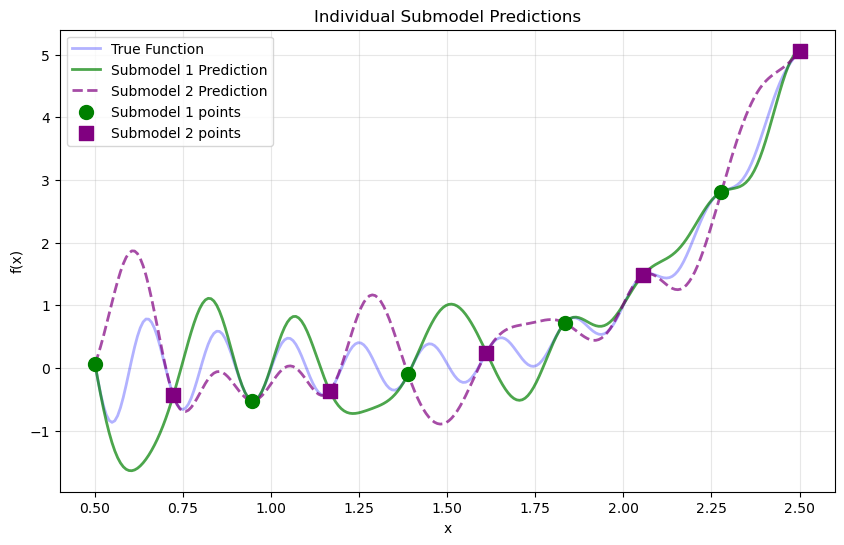

In [55]:
plt.figure(figsize=(10, 6))
plt.plot(X_test, y_true, 'b-', label='True Function', linewidth=2, alpha=0.3)
plt.plot(X_test.flatten(), submodel_vals[0].flatten(), 'g-',
         label='Submodel 1 Prediction', linewidth=2, alpha=0.7)
plt.plot(X_test.flatten(), submodel_vals[1].flatten(), 'purple', linestyle='--',
         label='Submodel 2 Prediction', linewidth=2, alpha=0.7)
plt.scatter(X_train[:5],
            f_fun(X_train[:5, 0].flatten()).reshape(-1, 1),
            color='green', s=100, marker='o', label='Submodel 1 points', zorder=5)
plt.scatter(X_train[5:],
            f_fun(X_train[5:, 0].flatten()).reshape(-1, 1),
            color='purple', s=100, marker='s', label='Submodel 2 points', zorder=5)
plt.title("Individual Submodel Predictions")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [56]:
import numpy as np
import sympy as sp
import itertools
from wdegp.wdegp import wdegp
from matplotlib import pyplot as plt
import utils

plt.rcParams.update({'font.size': 12})

In [57]:
# Random seed for reproducibility
random_seed = 0
np.random.seed(random_seed)

# GP configuration
n_order = 2  # Maximum derivative order (for center submodel - 2nd order)
n_bases = 2
lb_x, ub_x = -1.0, 1.0
lb_y, ub_y = -1.0, 1.0
points_per_axis = 4
kernel = "RQ"
kernel_type = "isotropic"
normalize = True
n_restart_optimizer = 15
swarm_size = 250
test_points_per_axis = 35

# Submodel point groups (using original grid indices)
submodel_point_groups = [
    [0, 3, 12, 15],                 # Submodel 1: Corners (no derivatives)
    [1, 2, 4, 8, 7, 11, 13, 14],    # Submodel 2: Edges (1st order)
    [5, 6, 9, 10]                   # Submodel 3: Center (2nd order)
]

In [58]:
def six_hump_camel_function(X, alg=np):
    """
    Six-hump camel function - a challenging 2D benchmark.

    Features:
    - Multiple local minima
    - Two global minima at approximately (0.0898, -0.7126) and (-0.0898, 0.7126)
    - Varying curvature across the domain

    Parameters
    ----------
    X : array_like
        Input array of shape (n, 2) with columns [x1, x2]
    alg : module
        Algorithm module (np for standard evaluation)

    Returns
    -------
    array_like
        Function values
    """
    x1 = X[:, 0]
    x2 = X[:, 1]
    return ((4 - 2.1 * x1**2 + (x1**4)/3.0) * x1**2 +
            x1*x2 + (-4 + 4*x2**2) * x2**2)

In [59]:
def generate_training_points():
    """Generate a 4×4 grid of training points."""
    x_vals = np.linspace(lb_x, ub_x, points_per_axis)
    y_vals = np.linspace(lb_y, ub_y, points_per_axis)
    return np.array(list(itertools.product(x_vals, y_vals)))

X_train_initial = generate_training_points()

print(f"Training points shape: {X_train_initial.shape}")
print(f"Total training points: {len(X_train_initial)}")
print(f"\nGrid layout (indices):")
grid_indices = np.arange(16).reshape(4, 4)
print(grid_indices)

Training points shape: (16, 2)
Total training points: 16

Grid layout (indices):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]


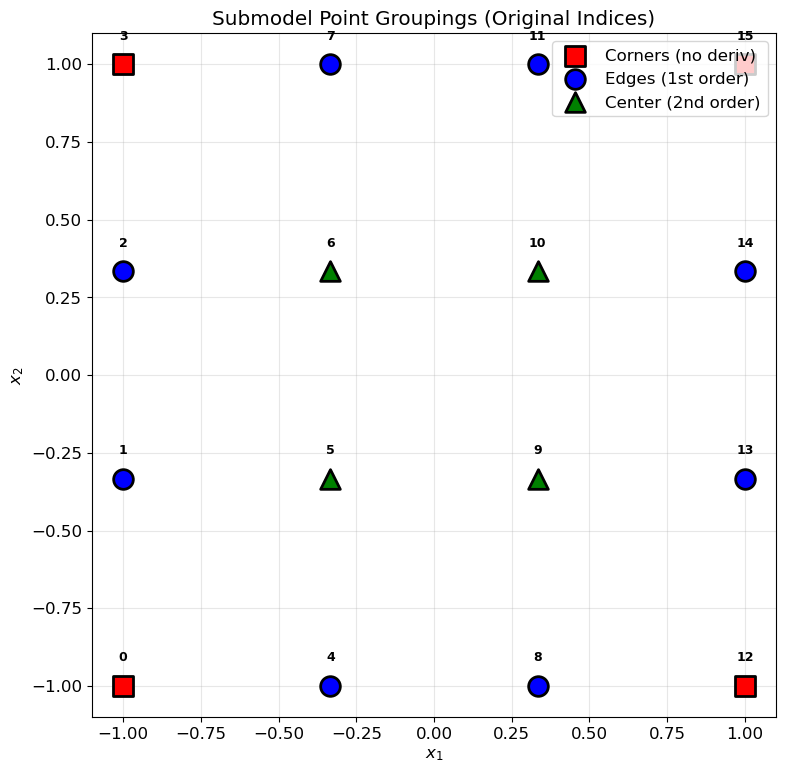

In [60]:
def visualize_submodel_groups(X_train, submodel_groups):
    """Visualize which points belong to which submodel."""
    fig, ax = plt.subplots(figsize=(8, 8))

    colors = ['red', 'blue', 'green']
    labels = ['Corners (no deriv)', 'Edges (1st order)', 'Center (2nd order)']
    markers = ['s', 'o', '^']

    for i, (group, color, label, marker) in enumerate(zip(submodel_groups, colors, labels, markers)):
        points = X_train[group]
        ax.scatter(points[:, 0], points[:, 1], c=color, s=200,
                  marker=marker, label=label, edgecolors='black', linewidths=2, zorder=5)

        # Add index labels
        for idx in group:
            ax.text(X_train[idx, 0], X_train[idx, 1] + 0.08, str(idx),
                   fontsize=9, ha='center', fontweight='bold')

    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title('Submodel Point Groupings (Original Indices)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

visualize_submodel_groups(X_train_initial, submodel_point_groups)

In [61]:
def reorder_training_data(X_train_initial, submodel_point_groups):
    """
    Reorder training data so each submodel's points are contiguous.

    Original indices are remapped to sequential positions:
    - Submodel 1 points → indices 0-3
    - Submodel 2 points → indices 4-11
    - Submodel 3 points → indices 12-15

    Returns
    -------
    X_train_reordered : array
        Reordered training points
    sequential_indices : list of lists
        Contiguous index ranges for each submodel
    reorder_map : list
        Mapping from new to original indices
    """
    # Flatten all submodel indices into a single reordering
    arbitrary_flat = list(itertools.chain.from_iterable(submodel_point_groups))

    # Find any unused points (none in this example, but code is general)
    all_indices = set(range(X_train_initial.shape[0]))
    used_indices = set(arbitrary_flat)
    unused_indices = sorted(list(all_indices - used_indices))

    # Create reordering map
    reorder_map = arbitrary_flat + unused_indices
    X_train_reordered = X_train_initial[reorder_map]

    # Generate sequential indices for each submodel
    sequential_indices = []
    current_pos = 0
    for group in submodel_point_groups:
        group_len = len(group)
        sequential_indices.append(list(range(current_pos, current_pos + group_len)))
        current_pos += group_len

    return X_train_reordered, sequential_indices, reorder_map

X_train_reordered, sequential_indices, reorder_map = reorder_training_data(
    X_train_initial, submodel_point_groups
)

print("Reordered training points shape:", X_train_reordered.shape)
print("\nSequential submodel indices:")
print(f"  Submodel 1 (corners): {sequential_indices[0]}")
print(f"  Submodel 2 (edges):   {sequential_indices[1]}")
print(f"  Submodel 3 (center):  {sequential_indices[2]}")
print("\nReordering map:")
print(f"  Original → Reordered: {reorder_map}")

Reordered training points shape: (16, 2)

Sequential submodel indices:
  Submodel 1 (corners): [0, 1, 2, 3]
  Submodel 2 (edges):   [4, 5, 6, 7, 8, 9, 10, 11]
  Submodel 3 (center):  [12, 13, 14, 15]

Reordering map:
  Original → Reordered: [0, 3, 12, 15, 1, 2, 4, 8, 7, 11, 13, 14, 5, 6, 9, 10]


In [62]:
def six_hump_camel_symbolic():
    """
    Create symbolic expression for the six-hump camel function.

    Returns
    -------
    expr : sympy expression
        Symbolic function
    x1, x2 : sympy symbols
        Input variables
    """
    x1, x2 = sp.symbols('x1 x2', real=True)
    expr = ((4 - 2.1 * x1**2 + (x1**4)/3.0) * x1**2 +
            x1*x2 + (-4 + 4*x2**2) * x2**2)
    return expr, x1, x2

def compute_derivatives_sympy(expr, x1, x2):
    """
    Compute all partial derivatives up to 2nd order using SymPy.

    Parameters
    ----------
    expr : sympy expression
        Function to differentiate
    x1, x2 : sympy symbols
        Variables

    Returns
    -------
    derivatives : dict
        Dictionary mapping derivative indices to lambdified functions
        Key format: (i, j) where i = order w.r.t. x1, j = order w.r.t. x2
    """
    derivatives = {}

    # First order derivatives
    derivatives[(1, 0)] = sp.lambdify((x1, x2), sp.diff(expr, x1), 'numpy')      # ∂f/∂x1
    derivatives[(0, 1)] = sp.lambdify((x1, x2), sp.diff(expr, x2), 'numpy')      # ∂f/∂x2

    # Second order derivatives
    derivatives[(2, 0)] = sp.lambdify((x1, x2), sp.diff(expr, x1, 2), 'numpy')   # ∂²f/∂x1²
    derivatives[(1, 1)] = sp.lambdify((x1, x2), sp.diff(expr, x1, x2), 'numpy')  # ∂²f/∂x1∂x2
    derivatives[(0, 2)] = sp.lambdify((x1, x2), sp.diff(expr, x2, 2), 'numpy')   # ∂²f/∂x2²

    return derivatives

def prepare_submodel_data(X_train, submodel_indices):
    """
    Prepare submodel data with heterogeneous derivative orders using SymPy.

    Submodel 1: Function values only (no derivatives)
    Submodel 2: Function values + 1st order derivatives
    Submodel 3: Function values + up to 2nd order derivatives

    Parameters
    ----------
    X_train : array
        Reordered training points
    submodel_indices : list of lists
        Contiguous indices for each submodel

    Returns
    -------
    submodel_data : list of lists
        Data for each submodel
    derivative_specs : list of lists
        Derivative specifications for each submodel (OTI format)
    """
    # Create symbolic function and compute derivatives
    print("Computing symbolic derivatives with SymPy...")
    expr, x1, x2 = six_hump_camel_symbolic()
    all_derivatives = compute_derivatives_sympy(expr, x1, x2)

    # Define derivative structures for each submodel using OTI format
    derivative_specs = [
        [],                              # Submodel 1: no derivatives
        utils.gen_OTI_indices(n_bases, 1),  # Submodel 2: ∂/∂x₁, ∂/∂x₂
        utils.gen_OTI_indices(n_bases, 2)   # Submodel 3: all up to 2nd order
    ]

    # Create tuple version for easier iteration with SymPy
    derivative_specs_tuples = [
        [],  # Submodel 1: no derivatives
        [(1, 0), (0, 1)],  # Submodel 2: 1st order only
        [(1, 0), (0, 1), (2, 0), (1, 1), (0, 2)]  # Submodel 3: up to 2nd order
    ]

    print("Derivative specifications:")
    for i, spec in enumerate(derivative_specs):
        if len(spec) == 0:
            print(f"  Submodel {i+1}: No derivatives")
        else:
            print(f"  Submodel {i+1}: {len(spec)} derivative types")
            print(f"    Examples: {spec[:3]}")

    # Compute function values at ALL training points (shared by all submodels)
    y_function_values = six_hump_camel_function(X_train, alg=np).reshape(-1, 1)

    submodel_data = []

    for k, point_indices in enumerate(submodel_indices):
        print(f"\nProcessing Submodel {k+1} (indices {point_indices[0]}-{point_indices[-1]})...")

        # Extract submodel points
        X_sub = X_train[point_indices]

        # Build data list: function values (all points) + derivatives (submodel points)
        current_submodel_data = [y_function_values]
        current_derivative_spec = derivative_specs_tuples[k]

        # Compute derivatives for this submodel
        for deriv_idx in current_derivative_spec:
            i, j = deriv_idx
            deriv_func = all_derivatives[(i, j)]

            # Evaluate derivative at submodel points
            deriv_values = np.array([
                deriv_func(X_sub[pt, 0], X_sub[pt, 1])
                for pt in range(len(X_sub))
            ]).reshape(-1, 1)

            current_submodel_data.append(deriv_values)

        print(f"  Function values: shape {current_submodel_data[0].shape}")
        print(f"  Derivative arrays: {len(current_submodel_data) - 1}")

        submodel_data.append(current_submodel_data)

    return submodel_data, derivative_specs

submodel_data, derivative_specs = prepare_submodel_data(
    X_train_reordered, sequential_indices
)

print(f"\n{'='*60}")
print("Summary of submodel data:")
for i, data in enumerate(submodel_data):
    print(f"  Submodel {i+1}: {len(data)} arrays")
    print(f"    - Array 0: Function values at ALL {len(data[0])} points")
    if len(sequential_indices[i]) > 0 and len(data) > 1:
        print(f"    - Arrays 1-{len(data)-1}: Derivatives at {len(sequential_indices[i])} points")

# Store for later verification
y_function_values = submodel_data[0][0]

Computing symbolic derivatives with SymPy...
Derivative specifications:
  Submodel 1: No derivatives
  Submodel 2: 1 derivative types
    Examples: [[[[1, 1]], [[2, 1]]]]
  Submodel 3: 2 derivative types
    Examples: [[[[1, 1]], [[2, 1]]], [[[1, 2]], [[1, 1], [2, 1]], [[2, 2]]]]

Processing Submodel 1 (indices 0-3)...
  Function values: shape (16, 1)
  Derivative arrays: 0

Processing Submodel 2 (indices 4-11)...
  Function values: shape (16, 1)
  Derivative arrays: 2

Processing Submodel 3 (indices 12-15)...
  Function values: shape (16, 1)
  Derivative arrays: 5

Summary of submodel data:
  Submodel 1: 1 arrays
    - Array 0: Function values at ALL 16 points
  Submodel 2: 3 arrays
    - Array 0: Function values at ALL 16 points
    - Arrays 1-2: Derivatives at 8 points
  Submodel 3: 6 arrays
    - Array 0: Function values at ALL 16 points
    - Arrays 1-5: Derivatives at 4 points


In [63]:
def build_and_optimize_gp(X_train, submodel_data, submodel_indices, derivative_specs):
    """
    Build and optimize the weighted DEGP model.

    Parameters
    ----------
    X_train : array
        Reordered training points (all 16 points)
    submodel_data : list of lists
        Data for each submodel
    submodel_indices : list of lists
        Contiguous indices for each submodel
    derivative_specs : list of lists
        Derivative specifications for each submodel

    Returns
    -------
    gp_model : wdegp
        Trained GP model
    params : dict
        Optimized hyperparameters
    """
    print("Building WDEGP model...")
    gp_model = wdegp(
        X_train,
        submodel_data,
        n_order,
        n_bases,
        submodel_indices,
        derivative_specs,
        normalize=normalize,
        kernel=kernel,
        kernel_type=kernel_type
    )

    print("Optimizing hyperparameters...")
    params = gp_model.optimize_hyperparameters(
        optimizer='jade',
        pop_size=100,
        n_generations=15,
        local_opt_every=None,
        debug=False
    )

    print("Optimization complete.")
    return gp_model, params

gp_model, params = build_and_optimize_gp(
    X_train_reordered, submodel_data, sequential_indices, derivative_specs
)

Building WDEGP model...
Optimizing hyperparameters...


Optimization complete.


In [64]:
# Create dense test grid
x_lin = np.linspace(lb_x, ub_x, test_points_per_axis)
y_lin = np.linspace(lb_y, ub_y, test_points_per_axis)
X1_grid, X2_grid = np.meshgrid(x_lin, y_lin)
X_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

print(f"Test grid: {test_points_per_axis}×{test_points_per_axis} = {len(X_test)} points")

# Predict on test grid
y_pred, submodel_vals = gp_model.predict(
    X_test, params, calc_cov=False, return_submodels=True
)

# Compute ground truth and error
y_true = six_hump_camel_function(X_test, alg=np)
nrmse = utils.nrmse(y_true, y_pred)
abs_error = np.abs(y_true - y_pred)

print(f"\nModel Performance:")
print(f"  NRMSE: {nrmse:.6f}")
print(f"  Max absolute error: {abs_error.max():.6f}")
print(f"  Mean absolute error: {abs_error.mean():.6f}")

Test grid: 35×35 = 1225 points



Model Performance:
  NRMSE: 0.020719
  Max absolute error: 0.479449
  Mean absolute error: 0.050244


In [65]:
# Verify function value interpolation at all reordered training points
y_pred_train = gp_model.predict(X_train_reordered, params, calc_cov=False)

print("Function value interpolation errors (reordered X_train):")
print("=" * 80)
for i in range(len(X_train_reordered)):
    error_abs = abs(y_pred_train[0, i] - y_function_values[i, 0])
    error_rel = error_abs / abs(y_function_values[i, 0]) if y_function_values[i, 0] != 0 else error_abs

    # Determine which submodel this point belongs to
    if i in sequential_indices[0]:
        submodel_id = 1
        deriv_order = "0th (no deriv)"
    elif i in sequential_indices[1]:
        submodel_id = 2
        deriv_order = "1st order"
    else:
        submodel_id = 3
        deriv_order = "2nd order"

    print(f"X_train[{i}] (SM{submodel_id}, {deriv_order}): "
          f"x=({X_train_reordered[i, 0]:.2f}, {X_train_reordered[i, 1]:.2f}), "
          f"Abs Error = {error_abs:.2e}, Rel Error = {error_rel:.2e}")

max_func_error = np.max(np.abs(y_pred_train.flatten() - y_function_values.flatten()))
print(f"\nMaximum absolute function value error: {max_func_error:.2e}")

# Verify derivative interpolation for Submodel 2 (1st order derivatives)
print("\n" + "=" * 80)
print("Derivative interpolation verification - SUBMODEL 2 (Edges, 1st order):")
print("=" * 80)

# Use small perturbation for finite differences
h = 1e-6

for local_i, global_i in enumerate(sequential_indices[1]):
    x_point = X_train_reordered[global_i]

    print(f"\nSubmodel 2 at X_train[{global_i}] (original index {submodel_point_groups[1][local_i]})")
    print(f"  Location: x₁={x_point[0]:.3f}, x₂={x_point[1]:.3f}")

    # Verify ∂f/∂x₁
    X_plus_x1 = x_point.copy().reshape(1, -1)
    X_minus_x1 = x_point.copy().reshape(1, -1)
    X_plus_x1[0, 0] += h
    X_minus_x1[0, 0] -= h

    _, submodel_vals_plus = gp_model.predict(X_plus_x1, params, calc_cov=False, return_submodels=True)
    _, submodel_vals_minus = gp_model.predict(X_minus_x1, params, calc_cov=False, return_submodels=True)

    fd_deriv_x1 = (submodel_vals_plus[1][0, 0] - submodel_vals_minus[1][0, 0]) / (2 * h)
    analytic_deriv_x1 = submodel_data[1][1][local_i, 0]

    error_x1_abs = abs(fd_deriv_x1 - analytic_deriv_x1)
    error_x1_rel = error_x1_abs / abs(analytic_deriv_x1) if analytic_deriv_x1 != 0 else error_x1_abs

    print(f"  ∂f/∂x₁ - Analytic: {analytic_deriv_x1:+.6f}, FD: {fd_deriv_x1:+.6f}")
    print(f"           Abs Error: {error_x1_abs:.2e}, Rel Error: {error_x1_rel:.2e}")

    # Verify ∂f/∂x₂
    X_plus_x2 = x_point.copy().reshape(1, -1)
    X_minus_x2 = x_point.copy().reshape(1, -1)
    X_plus_x2[0, 1] += h
    X_minus_x2[0, 1] -= h

    _, submodel_vals_plus = gp_model.predict(X_plus_x2, params, calc_cov=False, return_submodels=True)
    _, submodel_vals_minus = gp_model.predict(X_minus_x2, params, calc_cov=False, return_submodels=True)

    fd_deriv_x2 = (submodel_vals_plus[1][0, 0] - submodel_vals_minus[1][0, 0]) / (2 * h)
    analytic_deriv_x2 = submodel_data[1][2][local_i, 0]

    error_x2_abs = abs(fd_deriv_x2 - analytic_deriv_x2)
    error_x2_rel = error_x2_abs / abs(analytic_deriv_x2) if analytic_deriv_x2 != 0 else error_x2_abs

    print(f"  ∂f/∂x₂ - Analytic: {analytic_deriv_x2:+.6f}, FD: {fd_deriv_x2:+.6f}")
    print(f"           Abs Error: {error_x2_abs:.2e}, Rel Error: {error_x2_rel:.2e}")

# Verify derivative interpolation for Submodel 3 (up to 2nd order derivatives)
print("\n" + "=" * 80)
print("Derivative interpolation verification - SUBMODEL 3 (Center, up to 2nd order):")
print("=" * 80)
print("Note: Using larger h (1e-5) for 2nd order derivatives to improve numerical stability")
print("=" * 80)

# Use larger perturbation for second-order derivatives
h = 1e-3

for local_i, global_i in enumerate(sequential_indices[2]):
    x_point = X_train_reordered[global_i]

    print(f"\nSubmodel 3 at X_train[{global_i}] (original index {submodel_point_groups[2][local_i]})")
    print(f"  Location: x₁={x_point[0]:.3f}, x₂={x_point[1]:.3f}")

    # --- First order derivatives (using h=1e-6 for better accuracy) ---
    h_first = 1e-6

    # ∂f/∂x₁
    X_plus_x1 = x_point.copy().reshape(1, -1)
    X_minus_x1 = x_point.copy().reshape(1, -1)
    X_plus_x1[0, 0] += h_first
    X_minus_x1[0, 0] -= h_first

    _, submodel_vals_plus = gp_model.predict(X_plus_x1, params, calc_cov=False, return_submodels=True)
    _, submodel_vals_minus = gp_model.predict(X_minus_x1, params, calc_cov=False, return_submodels=True)

    fd_deriv_x1 = (submodel_vals_plus[2][0, 0] - submodel_vals_minus[2][0, 0]) / (2 * h_first)
    analytic_deriv_x1 = submodel_data[2][1][local_i, 0]

    error_x1_abs = abs(fd_deriv_x1 - analytic_deriv_x1)
    error_x1_rel = error_x1_abs / abs(analytic_deriv_x1) if analytic_deriv_x1 != 0 else error_x1_abs

    print(f"  ∂f/∂x₁ - Analytic: {analytic_deriv_x1:+.6f}, FD: {fd_deriv_x1:+.6f}")
    print(f"           Abs Error: {error_x1_abs:.2e}, Rel Error: {error_x1_rel:.2e}")

    # ∂f/∂x₂
    X_plus_x2 = x_point.copy().reshape(1, -1)
    X_minus_x2 = x_point.copy().reshape(1, -1)
    X_plus_x2[0, 1] += h_first
    X_minus_x2[0, 1] -= h_first

    _, submodel_vals_plus = gp_model.predict(X_plus_x2, params, calc_cov=False, return_submodels=True)
    _, submodel_vals_minus = gp_model.predict(X_minus_x2, params, calc_cov=False, return_submodels=True)

    fd_deriv_x2 = (submodel_vals_plus[2][0, 0] - submodel_vals_minus[2][0, 0]) / (2 * h_first)
    analytic_deriv_x2 = submodel_data[2][2][local_i, 0]

    error_x2_abs = abs(fd_deriv_x2 - analytic_deriv_x2)
    error_x2_rel = error_x2_abs / abs(analytic_deriv_x2) if analytic_deriv_x2 != 0 else error_x2_abs

    print(f"  ∂f/∂x₂ - Analytic: {analytic_deriv_x2:+.6f}, FD: {fd_deriv_x2:+.6f}")
    print(f"           Abs Error: {error_x2_abs:.2e}, Rel Error: {error_x2_rel:.2e}")

    # --- Second order derivatives (using h=1e-5 for stability) ---
    X_center = x_point.reshape(1, -1)
    _, submodel_vals_center = gp_model.predict(X_center, params, calc_cov=False, return_submodels=True)

    # ∂²f/∂x₁²
    X_plus_x1 = x_point.copy().reshape(1, -1)
    X_minus_x1 = x_point.copy().reshape(1, -1)
    X_plus_x1[0, 0] += h
    X_minus_x1[0, 0] -= h

    _, submodel_vals_plus = gp_model.predict(X_plus_x1, params, calc_cov=False, return_submodels=True)
    _, submodel_vals_minus = gp_model.predict(X_minus_x1, params, calc_cov=False, return_submodels=True)

    fd_deriv2_x1x1 = (submodel_vals_plus[2][0, 0] - 2*submodel_vals_center[2][0, 0] +
                      submodel_vals_minus[2][0, 0]) / (h**2)
    analytic_deriv2_x1x1 = submodel_data[2][3][local_i, 0]

    error_x1x1_abs = abs(fd_deriv2_x1x1 - analytic_deriv2_x1x1)
    error_x1x1_rel = error_x1x1_abs / abs(analytic_deriv2_x1x1) if analytic_deriv2_x1x1 != 0 else error_x1x1_abs

    print(f"  ∂²f/∂x₁² - Analytic: {analytic_deriv2_x1x1:+.6f}, FD: {fd_deriv2_x1x1:+.6f}")
    print(f"             Abs Error: {error_x1x1_abs:.2e}, Rel Error: {error_x1x1_rel:.2e}")

    # ∂²f/∂x₁∂x₂ (mixed partial)
    X_pp = x_point.copy().reshape(1, -1); X_pp[0, 0] += h; X_pp[0, 1] += h
    X_pm = x_point.copy().reshape(1, -1); X_pm[0, 0] += h; X_pm[0, 1] -= h
    X_mp = x_point.copy().reshape(1, -1); X_mp[0, 0] -= h; X_mp[0, 1] += h
    X_mm = x_point.copy().reshape(1, -1); X_mm[0, 0] -= h; X_mm[0, 1] -= h

    _, sm_pp = gp_model.predict(X_pp, params, calc_cov=False, return_submodels=True)
    _, sm_pm = gp_model.predict(X_pm, params, calc_cov=False, return_submodels=True)
    _, sm_mp = gp_model.predict(X_mp, params, calc_cov=False, return_submodels=True)
    _, sm_mm = gp_model.predict(X_mm, params, calc_cov=False, return_submodels=True)

    fd_deriv2_x1x2 = (sm_pp[2][0, 0] - sm_pm[2][0, 0] - sm_mp[2][0, 0] + sm_mm[2][0, 0]) / (4 * h**2)
    analytic_deriv2_x1x2 = submodel_data[2][4][local_i, 0]

    error_x1x2_abs = abs(fd_deriv2_x1x2 - analytic_deriv2_x1x2)
    error_x1x2_rel = error_x1x2_abs / abs(analytic_deriv2_x1x2) if analytic_deriv2_x1x2 != 0 else error_x1x2_abs

    print(f"  ∂²f/∂x₁∂x₂ - Analytic: {analytic_deriv2_x1x2:+.6f}, FD: {fd_deriv2_x1x2:+.6f}")
    print(f"               Abs Error: {error_x1x2_abs:.2e}, Rel Error: {error_x1x2_rel:.2e}")

    # ∂²f/∂x₂²
    X_plus_x2 = x_point.copy().reshape(1, -1)
    X_minus_x2 = x_point.copy().reshape(1, -1)
    X_plus_x2[0, 1] += h
    X_minus_x2[0, 1] -= h

    _, submodel_vals_plus = gp_model.predict(X_plus_x2, params, calc_cov=False, return_submodels=True)
    _, submodel_vals_minus = gp_model.predict(X_minus_x2, params, calc_cov=False, return_submodels=True)

    fd_deriv2_x2x2 = (submodel_vals_plus[2][0, 0] - 2*submodel_vals_center[2][0, 0] +
                      submodel_vals_minus[2][0, 0]) / (h**2)
    analytic_deriv2_x2x2 = submodel_data[2][5][local_i, 0]

    error_x2x2_abs = abs(fd_deriv2_x2x2 - analytic_deriv2_x2x2)
    error_x2x2_rel = error_x2x2_abs / abs(analytic_deriv2_x2x2) if analytic_deriv2_x2x2 != 0 else error_x2x2_abs

    print(f"  ∂²f/∂x₂² - Analytic: {analytic_deriv2_x2x2:+.6f}, FD: {fd_deriv2_x2x2:+.6f}")
    print(f"             Abs Error: {error_x2x2_abs:.2e}, Rel Error: {error_x2x2_rel:.2e}")

print("\n" + "=" * 80)
print("Interpolation verification complete!")
print("\n" + "=" * 80)
print("SUMMARY:")
print(f"  - Function values: enforced at ALL {len(X_train_reordered)} training points")
print(f"  - Submodel 1 (Corners): {len(sequential_indices[0])} points with NO derivatives")
print(f"    Indices: {sequential_indices[0]} (original: {submodel_point_groups[0]})")
print(f"  - Submodel 2 (Edges): {len(sequential_indices[1])} points with 1st order derivatives")
print(f"    Indices: {sequential_indices[1]} (original: {submodel_point_groups[1]})")
print(f"    Verified: ∂f/∂x₁, ∂f/∂x₂")
print(f"  - Submodel 3 (Center): {len(sequential_indices[2])} points with up to 2nd order derivatives")
print(f"    Indices: {sequential_indices[2]} (original: {submodel_point_groups[2]})")
print(f"    Verified: ∂f/∂x₁, ∂f/∂x₂, ∂²f/∂x₁², ∂²f/∂x₁∂x₂, ∂²f/∂x₂²")
print(f"  - Total submodels: 3 (with heterogeneous derivative orders)")
print(f"  - Verification method: Finite differences on individual submodels")
print(f"  - Note: Used h=1e-3 for 2nd order derivatives (improved numerical stability)")
print("=" * 80)

Function value interpolation errors (reordered X_train):
X_train[0] (SM1, 0th (no deriv)): x=(-1.00, -1.00), Abs Error = 3.25e-12, Rel Error = 1.01e-12
X_train[1] (SM1, 0th (no deriv)): x=(-1.00, 1.00), Abs Error = 2.98e-12, Rel Error = 2.42e-12
X_train[2] (SM1, 0th (no deriv)): x=(1.00, -1.00), Abs Error = 2.00e-12, Rel Error = 1.62e-12
X_train[3] (SM1, 0th (no deriv)): x=(1.00, 1.00), Abs Error = 2.16e-12, Rel Error = 6.68e-13
X_train[4] (SM2, 1st order): x=(-1.00, -0.33), Abs Error = 1.75e-10, Rel Error = 8.05e-11
X_train[5] (SM2, 1st order): x=(-1.00, 0.33), Abs Error = 5.98e-11, Rel Error = 3.97e-11
X_train[6] (SM2, 1st order): x=(-0.33, -1.00), Abs Error = 8.69e-11, Rel Error = 1.15e-10
X_train[7] (SM2, 1st order): x=(0.33, -1.00), Abs Error = 8.81e-11, Rel Error = 1.03e-09
X_train[8] (SM2, 1st order): x=(-0.33, 1.00), Abs Error = 6.54e-11, Rel Error = 7.63e-10
X_train[9] (SM2, 1st order): x=(0.33, 1.00), Abs Error = 1.16e-10, Rel Error = 1.55e-10
X_train[10] (SM2, 1st order): x=

  ∂f/∂x₁ - Analytic: -2.697119, FD: -2.694116
           Abs Error: 3.00e-03, Rel Error: 1.11e-03
  ∂f/∂x₂ - Analytic: +1.740741, FD: +1.741412
           Abs Error: 6.71e-04, Rel Error: 3.86e-04
  ∂²f/∂x₁² - Analytic: +5.323457, FD: +5.333346
             Abs Error: 9.89e-03, Rel Error: 1.86e-03


  ∂²f/∂x₁∂x₂ - Analytic: +1.000000, FD: +0.997820
               Abs Error: 2.18e-03, Rel Error: 2.18e-03
  ∂²f/∂x₂² - Analytic: -2.666667, FD: -2.656455
             Abs Error: 1.02e-02, Rel Error: 3.83e-03

Submodel 3 at X_train[13] (original index 6)
  Location: x₁=-0.333, x₂=0.333
  ∂f/∂x₁ - Analytic: -2.030453, FD: -2.030986
           Abs Error: 5.33e-04, Rel Error: 2.63e-04
  ∂f/∂x₂ - Analytic: -2.407407, FD: -2.407627
           Abs Error: 2.20e-04, Rel Error: 9.14e-05
  ∂²f/∂x₁² - Analytic: +5.323457, FD: +5.322135
             Abs Error: 1.32e-03, Rel Error: 2.48e-04
  ∂²f/∂x₁∂x₂ - Analytic: +1.000000, FD: +1.000244
               Abs Error: 2.44e-04, Rel Error: 2.44e-04
  ∂²f/∂x₂² - Analytic: -2.666667, FD: -2.668263
             Abs Error: 1.60e-03, Rel Error: 5.99e-04

Submodel 3 at X_train[14] (original index 9)
  Location: x₁=0.333, x₂=-0.333
  ∂f/∂x₁ - Analytic: +2.030453, FD: +2.029978
           Abs Error: 4.74e-04, Rel Error: 2.34e-04
  ∂f/∂x₂ - Analytic: +2.407407, 

  ∂²f/∂x₁∂x₂ - Analytic: +1.000000, FD: +1.000260
               Abs Error: 2.60e-04, Rel Error: 2.60e-04
  ∂²f/∂x₂² - Analytic: -2.666667, FD: -2.660328
             Abs Error: 6.34e-03, Rel Error: 2.38e-03

Interpolation verification complete!

SUMMARY:
  - Function values: enforced at ALL 16 training points
  - Submodel 1 (Corners): 4 points with NO derivatives
    Indices: [0, 1, 2, 3] (original: [0, 3, 12, 15])
  - Submodel 2 (Edges): 8 points with 1st order derivatives
    Indices: [4, 5, 6, 7, 8, 9, 10, 11] (original: [1, 2, 4, 8, 7, 11, 13, 14])
    Verified: ∂f/∂x₁, ∂f/∂x₂
  - Submodel 3 (Center): 4 points with up to 2nd order derivatives
    Indices: [12, 13, 14, 15] (original: [5, 6, 9, 10])
    Verified: ∂f/∂x₁, ∂f/∂x₂, ∂²f/∂x₁², ∂²f/∂x₁∂x₂, ∂²f/∂x₂²
  - Total submodels: 3 (with heterogeneous derivative orders)
  - Verification method: Finite differences on individual submodels
  - Note: Used h=1e-3 for 2nd order derivatives (improved numerical stability)


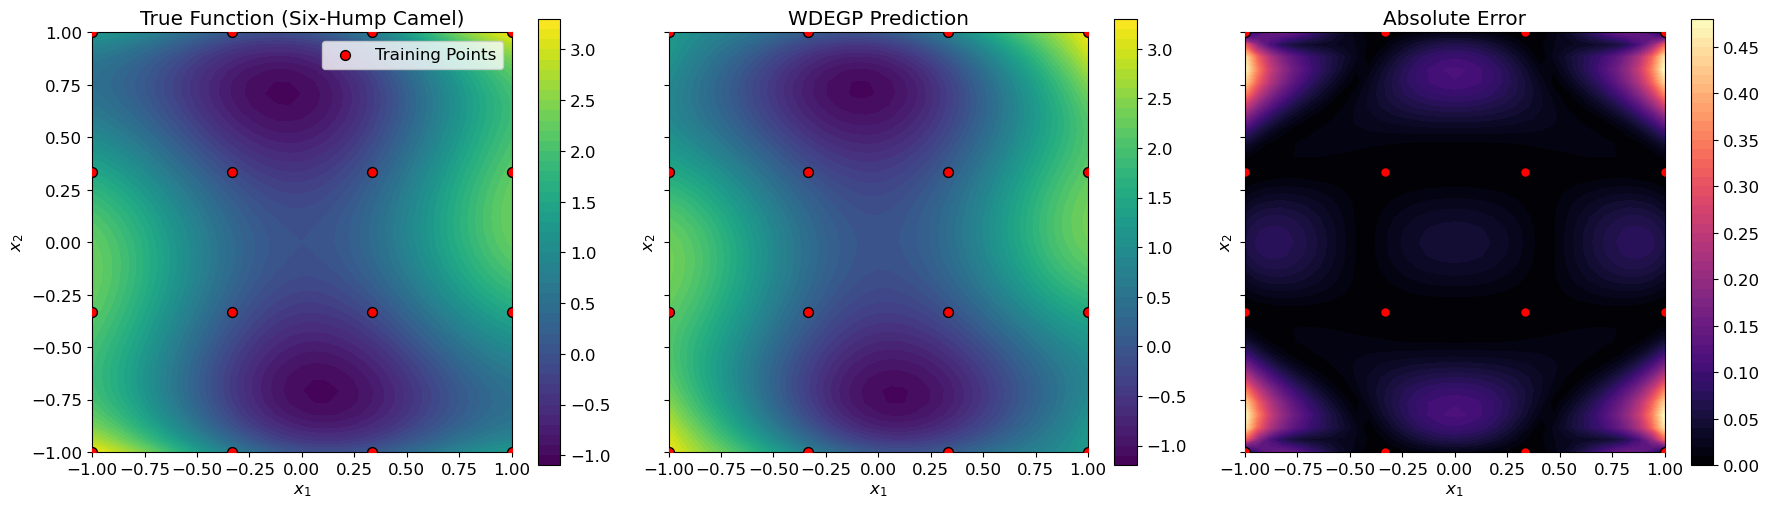

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# True function
c1 = axes[0].contourf(X1_grid, X2_grid,
                      y_true.reshape(test_points_per_axis, test_points_per_axis),
                      levels=50, cmap="viridis")
fig.colorbar(c1, ax=axes[0])
axes[0].set_title("True Function (Six-Hump Camel)")
axes[0].scatter(X_train_initial[:, 0], X_train_initial[:, 1],
                c="red", edgecolor="k", s=50, label="Training Points", zorder=5)
axes[0].legend()

# GP prediction
c2 = axes[1].contourf(X1_grid, X2_grid,
                      y_pred.reshape(test_points_per_axis, test_points_per_axis),
                      levels=50, cmap="viridis")
fig.colorbar(c2, ax=axes[1])
axes[1].set_title("WDEGP Prediction")
axes[1].scatter(X_train_initial[:, 0], X_train_initial[:, 1],
                c="red", edgecolor="k", s=50, zorder=5)

# Absolute error
c3 = axes[2].contourf(X1_grid, X2_grid,
                      abs_error.reshape(test_points_per_axis, test_points_per_axis),
                      levels=50, cmap="magma")
fig.colorbar(c3, ax=axes[2])
axes[2].set_title("Absolute Error")
axes[2].scatter(X_train_initial[:, 0], X_train_initial[:, 1],
                c="red", edgecolor="k", s=50, zorder=5)

for ax in axes:
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

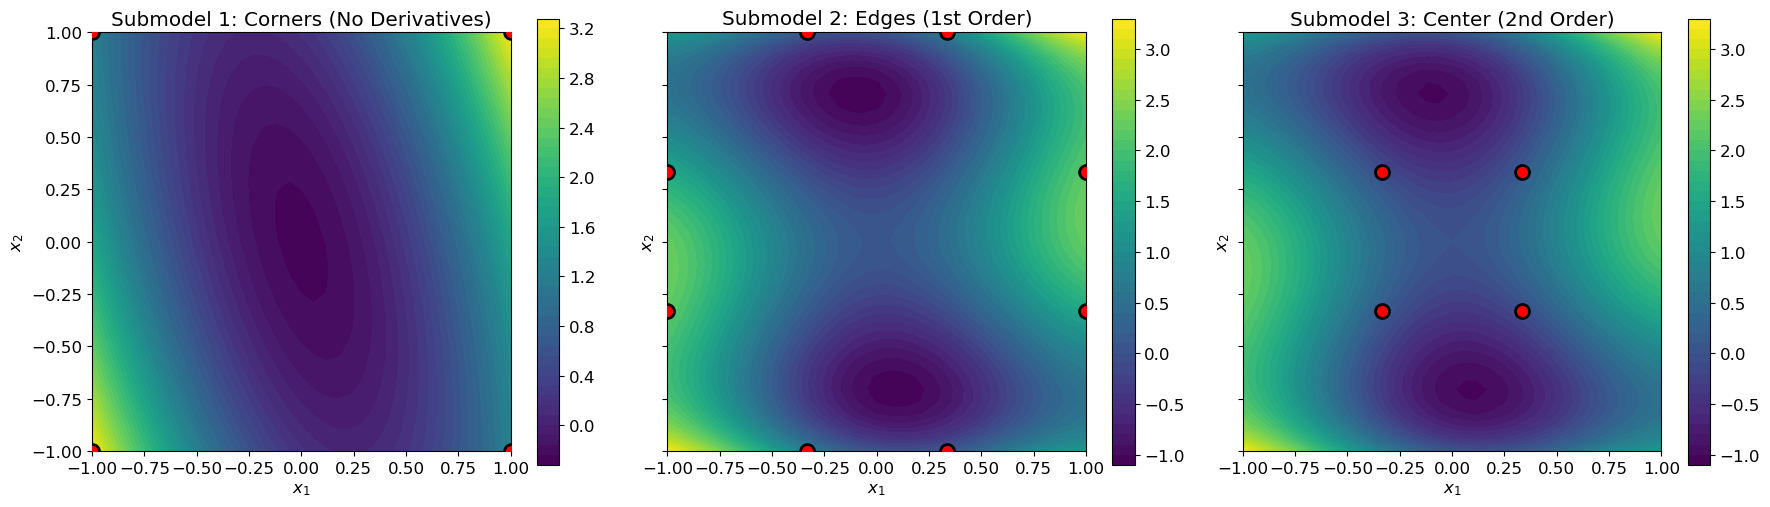

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

submodel_titles = [
    "Submodel 1: Corners (No Derivatives)",
    "Submodel 2: Edges (1st Order)",
    "Submodel 3: Center (2nd Order)"
]

for i, (ax, title) in enumerate(zip(axes, submodel_titles)):
    c = ax.contourf(X1_grid, X2_grid,
                   submodel_vals[i].reshape(test_points_per_axis, test_points_per_axis),
                   levels=50, cmap="viridis")
    fig.colorbar(c, ax=ax)
    ax.set_title(title)

    # Highlight this submodel's training points
    submodel_points = X_train_reordered[sequential_indices[i]]
    ax.scatter(submodel_points[:, 0], submodel_points[:, 1],
              c='red', s=100, edgecolor='k', linewidths=2, zorder=5)

    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()